In [305]:
print("Hello World!")

Hello World!


In [306]:
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu128

Looking in indexes: https://download.pytorch.org/whl/cu128



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [307]:
!pip install ipykernel



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [308]:
import torch

# 1. Check if CUDA is available
print(f"CUDA available: {torch.cuda.is_available()}")

# 2. Get the name of the active GPU
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")

CUDA available: True
GPU Name: NVIDIA GeForce RTX 5070 Laptop GPU
CUDA Version: 12.8


In [309]:
!pip install sumo


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [310]:
import os
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

import xml.etree.ElementTree as ET
import traci


In [415]:
import importlib

import functions.analysis as analysis
importlib.reload(analysis)


<module 'functions.analysis' from 'c:\\Users\\Yura Sannikov\\Учеба\\НИР-диплом26\\Папка с кодомм\\git\\functions\\analysis.py'>

In [312]:
def initialize(grids=3,lanes=2,length=400):
    os.system("netgenerate --grid --grid.number="+str(grids)+"" \
    " -L="+str(lanes)+" --tls.guess --grid.length="+str(length)+" --output-file=grid.net.xml")


In [313]:
def get_passed_count(detector_id):
    # Get the list of vehicles that passed the detector in the last step
    vehicle_data = traci.inductionloop.getLastIntervalVehicleNumber(detector_id)
    # The count is the length of the data list
    return vehicle_data
    # return len(vehicle_data)


In [314]:
import sumolib

In [315]:
from enum import Enum
from itertools import chain


In [316]:
class DirectionOfLane(str, Enum):
    '''
    какому направлению принадлежит полоса
    '''
    HORIZONTAL = "HOR"
    VERTICAL = "VER"


In [317]:
'A' > 'B' 

False

In [318]:
import re

parts = list(filter(None, re.split(r'[a-zA-Zа-яА-Я]+', 'A1B1_1'.split('_')[0])))
print(parts)

['1', '1']


In [319]:
'A1B1_1'.split('_')[0]

'A1B1'

In [320]:
def getLetters(str_):
    return list(filter(None, re.split(r'[a-zA-Zа-яА-Я]+', str_)))
def getDigits(str_):
    return list(filter(None, re.split(r'\d+', str_)))

In [321]:
def getLaneDirection(laneId):
    direction = "HOR" if laneId.count(laneId[0]) > 1 else "VER"
    if direction == "VER":
        parts = getDigits(laneId.split('_')[0])
        direction_of_moving = "DOWN" if parts[0] < parts[1] else "UP"
    else:
        parts = getLetters(laneId.split('_')[0])
        direction_of_moving = "RIGHT" if parts[0] < parts[1] else "LEFT"
    return f"{direction}_{direction_of_moving}"



In [411]:
def create_additional_with_e1_detectors(net_xml_path, path_to_save_data, output_path="additional.xml"):
    '''
    net_xml_path - путь до папки с сетью дорог
    path_to_save_data - путь до папки, куда будет сохраняться информация симуляции для каждого детектора
    output_path - выходной файл, для grid.sumocfg
    
    '''
    tree = ET.parse(net_xml_path)
    root = tree.getroot()
    # Загружаем сеть через sumolib
    net = sumolib.net.readNet(net_xml_path)
    
    additional_root = ET.Element("additional")
    
    # Находим все junction и их входящие lane
    for junction in root.findall("junction"):
        junction_id = junction.get("id")
        if not junction_id:
            continue
        
        # если не светофор
        if junction.get("type") != "traffic_light":
            continue
        
        junction_sumolib = None
        # Получаем объект перекрестка из sumolib
        try:
            junction_sumolib = net.getNode(junction_id)
        except:
            print(f"Предупреждение: перекресток {junction_id} не найден в sumolib")
            continue

        # Ищем все connection, ведущие к этому junction
        connections = root.findall(f".//connection[@tl='{junction_id}']")
        lanes = set()
        
        for conn in connections:
            edge_id = conn.get("from")
            lane_idx = conn.get("fromLane")
            if edge_id and lane_idx:
                lanes.add(f"{edge_id}_{lane_idx}")
        # Создаем детектор E1 и E2 (LaneArea) для каждой полосы
        for i, lane_id in enumerate(lanes):
            lane_id_direction = f"{lane_id}_{getLaneDirection(lane_id)}_{i}"
            # print(lane_id_direction)
            # ============ Детектор E1 (inductionLoop) ============
            detector = ET.SubElement(additional_root, "inductionLoop")
            detector.set("id", f"{junction_id}_E1_{lane_id_direction}")
            detector.set("lane", lane_id)
            detector.set("pos", "-10")
            detector.set("period", "1")
            os.makedirs(path_to_save_data, exist_ok=True)
            detector.set("file", f"{path_to_save_data}/detector_{junction_id}_{i}.xml")
            # ============ Детектор E2 (laneAreaDetector) ============
            e2_detector = ET.SubElement(additional_root, "laneAreaDetector")
            e2_detector.set("id", f"{junction_id}_E2_{lane_id_direction}")
            
            e2_detector.set("lane", lane_id)
            e2_detector.set("pos", "-150")  # Начинаем за 150 метров до стоп-линии
            e2_detector.set("length", "150")  # Длина зоны детектора 150 метров
            e2_detector.set("period", "1")  # Частота обновления (сек)
            e2_detector.set("vehicles", "all")  # Учитывать все ТС (не только пассажирские)
            e2_detector.set("file", f"{path_to_save_data}/detector_{junction_id}_{i}_E2.xml")

        # Создаем детекторы для внутренних полос (через sumolib)
        allConnections = set(junction_sumolib.getConnections())
        # print(allConnections)
        for idx, connection in enumerate(allConnections):
            via_lane_id = connection.getViaLaneID()
            # print(via_lane_id)
            if via_lane_id:
                length = 10.0
                e2_intersection = ET.SubElement(additional_root, "laneAreaDetector")
                e2_intersection.set("id", f"{junction_id}_INTERSECTION_E2_{idx}")
                e2_intersection.set("lane", via_lane_id)
                e2_intersection.set("pos", "0")  # Начало зоны
                e2_intersection.set("length", str(length))
                e2_intersection.set("period", "1")
                e2_intersection.set("friendlyPos", "true")
                e2_intersection.set("file", f"{path_to_save_data}/intersection_{junction_id}_{idx}.xml")
    
    tree_out = ET.ElementTree(additional_root)
    ET.indent(tree_out, space="  ")
    tree_out.write(output_path, encoding="UTF-8", xml_declaration=True)

In [323]:
{'B1A1_0', 'A2A1_1', 'A0A1_0', 'B1A1_1', 'A2A1_0', 'A0A1_1'}
('A2A1_0', 'A2A1_1', 'A2A1_1', 'A2A1_1', 'B1A1_0', 'B1A1_1', 'B1A1_1', 'B1A1_1', 'A0A1_0', 'A0A1_0', 'A0A1_1', 'A0A1_1')

('A2A1_0',
 'A2A1_1',
 'A2A1_1',
 'A2A1_1',
 'B1A1_0',
 'B1A1_1',
 'B1A1_1',
 'B1A1_1',
 'A0A1_0',
 'A0A1_0',
 'A0A1_1',
 'A0A1_1')

In [324]:
def getPhaseDirection(phaseNum, prevPhase: str):
    if phaseNum == 0 or phaseNum == 1:
        return "HOR"
    if phaseNum == 2 or phaseNum == 3:
        return "VER"
    if phaseNum == 4:
        return "NONE"
    return prevPhase

In [360]:
def setTrafficLightFazes(id, horizontal_light_duration, vertical_light_duration, yellow_light_duration = 3.0, with_all_red_phase= False):
    # Все светофоры идущие по часовой стрелке с правой lane
    n_signals = traci.trafficlight.getControlledLanes(id)
    print(n_signals)
    phases = []
    # Установка продолжительности зеленого сигнала для горизонтального направления
    # Разбиваем на 4 списка по условиям:
    listRight = [x for x in n_signals if 'RIGHT' in getLaneDirection(x) ]      # Все lanes с направлением вправо
    listLeft = [x for x in n_signals if 'LEFT' in getLaneDirection(x)]  # Все lanes с направлением влево
    listUp = [x for x in n_signals if 'UP' in getLaneDirection(x)]  # Все lanes с направлением вверх
    listDown = [x for x in n_signals if 'DOWN' in getLaneDirection(x)]     # Все lanes с направлением вниз
    
    stateHorizontalGreen = 'g'*len(listLeft) + 'r'*len(listUp) + 'g'*len(listRight) + 'r'*len(listDown)
    stateToVerticalGreen = 'y'*len(listLeft) + 'r'*len(listUp) + 'y'*len(listRight) + 'r'*len(listDown)
    stateVerticalGreen = 'r'*len(listLeft) + 'g'*len(listUp) + 'r'*len(listRight) + 'g'*len(listDown)
    stateToHorizontalGreen = 'r'*len(listLeft) + 'y'*len(listUp) + 'r'*len(listRight) + 'y'*len(listDown)

    phases.append(traci.trafficlight.Phase(horizontal_light_duration, stateHorizontalGreen, 0, 0))
    # Установка продолжительности переключения на красный сигнал для горизонтального направления
    phases.append(traci.trafficlight.Phase(yellow_light_duration, stateToVerticalGreen, 0, 0))
    # Установка продолжительности красного сигнала для горизонтального направления
    phases.append(traci.trafficlight.Phase(vertical_light_duration, stateVerticalGreen, 0, 0))
    # Установка продолжительности переключения на зеленый сигнал для горизонтального направления
    phases.append(traci.trafficlight.Phase(yellow_light_duration, stateToHorizontalGreen, 0, 0))
    logic = traci.trafficlight.Logic("0", 0, 0, phases)
    
    # print(logic)

    traci.trafficlight.setCompleteRedYellowGreenDefinition(id, logic)

def trafficLightsFazesForPredict(tls_id):
    '''Добавляет в программу "Все красные", чтобы установить всем направлениям краасный цвет'''
    program = traci.trafficlight.getCompleteRedYellowGreenDefinition(tls_id)
    phases = []
    phases = list(program[0].phases)
    n_signals = len(traci.trafficlight.getControlledLanes(tls_id))
    
    before_red_phase = traci.trafficlight.Phase(
        4, 'y' * n_signals, 0, 0
    )

    all_red_phase = traci.trafficlight.Phase(
        1, 'r' * n_signals, 0, 0
    )

    # Добавляем фазу в программу
    phases.append(all_red_phase)
    phases.append(before_red_phase)
    # print(phases)
    # Устанавливаем новую программу
    logic = traci.trafficlight.Logic("0", 0, 0, phases)
    traci.trafficlight.setProgramLogic(tls_id, logic)
    traci.trafficlight.setPhase(tls_id, len(phases) - 2)

In [382]:
def getTidAreas(tId, areas):
    return [item for item in areas if tId in item.split('_')[0]]


In [395]:
def get_all_vehiclesCount_for_traffic_light(trafficLightId, allInductionLoopIds):
    curSum = 0
    trafficLightIndicators = getTidAreas(trafficLightId, allInductionLoopIds)
    for detector_id in trafficLightIndicators:
        # if trafficLightId == 'B1':
            # print(detector_id,': ', traci.inductionloop.getLastIntervalVehicleIDs(detector_id))
        curSum +=traci.inductionloop.getLastIntervalVehicleNumber(detector_id)
    return curSum

In [327]:
def saveToCSV(data, path):
    df = pd.DataFrame(data)
    # Save to CSV (index=False prevents adding a row number column)
    df.to_csv(path, index=False)

In [328]:
from collections import Counter
Counter()

Counter()

In [329]:
columns = ['time_of_info',
                    'count_to_r',
                    'count_to_l',
                    'count_to_b',
                    'count_to_t',
                    'count_stuck_middle',
                    'count_stuck_to_r',
                    'count_stuck_to_l',
                    'count_stuck_to_b',
                    'count_stuck_to_t',
                    'is_jam_next_l',
                    'is_jam_next_r',
                    'is_jam_next_t',
                    'is_jam_next_b',
                    'is_green_horizontal',
                    'is_green_vertical',
                    'y',
                    ]
feature_cols = columns[1:-1]
pred_col = columns[-1]

columns_for_tls = ['time_of_info', 'tls_id']
columns_for_tls.extend(feature_cols)
columns_for_tls.extend(pred_col)
columns_for_tls.extend(['jams_count','jams_time','jams_car_count'])
print(columns_for_tls)

['time_of_info', 'tls_id', 'count_to_r', 'count_to_l', 'count_to_b', 'count_to_t', 'count_stuck_middle', 'count_stuck_to_r', 'count_stuck_to_l', 'count_stuck_to_b', 'count_stuck_to_t', 'is_jam_next_l', 'is_jam_next_r', 'is_jam_next_t', 'is_jam_next_b', 'is_green_horizontal', 'is_green_vertical', 'y', 'jams_count', 'jams_time', 'jams_car_count']


In [330]:

def addToDirectionSet(_set: set, trackId):
    if trackId not in _set:
      _set.add(trackId)

def addToDirectionCounter(_counter: Counter, trackId, skipCheck=False):
    if skipCheck or trackId not in _counter:
      _counter.update([trackId])
    
def removeFromSet(_set: set, trackId):
    if trackId in _set:
      _set.remove(trackId)
def removeFromCounter(_counter: Counter, trackId):
    if trackId in _counter:
      del _counter[trackId]

def removeFromOtherStuckCounters(trackId, counters: list[Counter]):
    for c in counters:
       removeFromCounter(c, trackId)

def removeFromOtherCurrentSets(trackId, sets: list[set]):
    for s in sets:
       removeFromSet(s, trackId)
  
def addToMiddleCounter(trackId, objects_stuck_middle: Counter, sets: list[set], counters: list[Counter]):
    if trackId not in objects_stuck_middle:
      objects_stuck_middle.update([trackId])
      removeFromOtherStuckCounters(trackId, counters=counters)
      removeFromOtherCurrentSets(trackId, sets=sets)

In [331]:
def deleteOldKeys(_counter: Counter, actual_keys: set):
    # Оставляем только те ключи, которые есть в множестве
    return Counter({k:_counter[k] for k in _counter if k in actual_keys})


In [332]:
c = Counter({'a': 1, 'b': 2, 'c': 3, 'd': 4})
keep_keys = ['a', 'c', 'x']

# Превращаем список в множество для быстрого поиска (O(1))
keys_set = set(keep_keys)

# Оставляем только те ключи, которые есть в множестве
c = deleteOldKeys(c, keys_set)

print(c) 


Counter({'c': 3, 'a': 1})


In [333]:
def getStuckFor2Switches(_counter: Counter):
    return [item for item, count in _counter.items() if count > 2]

def getTrullyStuck(_counter: Counter):
    '''
    Возвращает количество машин, которые простояли в области n больше 2 итераций
    '''
    return len(getStuckFor2Switches(_counter))

def isJamInLane(_counter: Counter):
    return 1 if getTrullyStuck(_counter) > 0 else 0

In [385]:
def updateGreenInfo(currentInfoMap, current_tls_phase, trafficLightId):
    if current_tls_phase == "VER":
        currentInfoMap[trafficLightId]['is_green_vertical'] = 1
        currentInfoMap[trafficLightId]['is_green_horizontal'] = 0
    if current_tls_phase == "HOR":
        currentInfoMap[trafficLightId]['is_green_vertical'] = 0
        currentInfoMap[trafficLightId]['is_green_horizontal'] = 1
    if current_tls_phase == "NONE":
        currentInfoMap[trafficLightId]['is_green_vertical'] = 0
        currentInfoMap[trafficLightId]['is_green_horizontal'] = 0

def updateJamCounters(currentInfoMap, trafficLightId, curObjects: str, direction: str):
    '''обновить счетчики пробок'''

    is_jam_str = f"is_jam_{direction}"
    jams_count_str = f"jams_count_{direction}"
    jams_car_count_str = f"jams_car_count_{direction}"
    jam_objects_str = f"jam_objects_{direction}"
    jams_time_str = f"jams_time_{direction}"

    info = currentInfoMap[trafficLightId]
    counter_of_objects = info[curObjects]
    new_jam = isJamInLane(counter_of_objects)
    old_jam = info[is_jam_str]
    # если появилась пробка, обновляем счетчик пробок
    if old_jam == 0 and new_jam == 1:
            currentInfoMap[trafficLightId][jams_count_str] += 1
    elif old_jam == 1 and new_jam == 0:
            # если пробка закончилась, обновляем счетчик машин учавствовавших в пробке
            currentInfoMap[trafficLightId][jams_car_count_str] += len(info[jam_objects_str])
            currentInfoMap[trafficLightId][jam_objects_str] = set()
    # если в текущий момент пробка, обновляемм счетчик времени проведенного в пробке
    if new_jam == 1:
            currentInfoMap[trafficLightId][jams_time_str] += 1
            currentInfoMap[trafficLightId][jam_objects_str].update(getStuckFor2Switches(counter_of_objects))
    
    currentInfoMap[trafficLightId][is_jam_str] = new_jam

def updateInfoMap(currentInfoMap, trafficLightId, allLaneAreas, skipCheck = False):
    trafficLightAreas = getTidAreas(tId=trafficLightId, areas=allLaneAreas)

    # print('========', trafficLightId, '===========')
    
    previous_tls_phase = currentInfoMap[trafficLightId]['previous_tls_phase']
    current_tls_phase = getPhaseDirection(traci.trafficlight.getPhase(trafficLightId), previous_tls_phase)
    isPhaseChanged = previous_tls_phase != current_tls_phase
    
    # Проверяем изменение сигнала на светофоре 
    if isPhaseChanged:
         skipCheck = True
    
    currentInfoMap[trafficLightId]['previous_tls_phase'] = current_tls_phase
    updateGreenInfo(currentInfoMap=currentInfoMap, current_tls_phase=current_tls_phase, trafficLightId=trafficLightId)
    for line_id in trafficLightAreas:
        ids = traci.lanearea.getLastStepVehicleIDs(line_id)
        ids_set = set(ids)
        if 'INTERSECTION' in line_id:
            for ix in ids:
                addToDirectionCounter(_counter=currentInfoMap[trafficLightId]['objects_stuck_middle'], trackId=ix, skipCheck=skipCheck)
                currentInfoMap[trafficLightId]['objects_stuck_middle'] = deleteOldKeys(_counter=currentInfoMap[trafficLightId]['objects_stuck_middle'],
                                                                                       actual_keys=ids_set)
        elif 'RIGHT' in line_id:
            for ix in ids:
                addToDirectionCounter(_counter=currentInfoMap[trafficLightId]['objects_stuck_to_r'], trackId=ix, skipCheck=skipCheck)
                currentInfoMap[trafficLightId]['objects_stuck_to_r'] = deleteOldKeys(_counter=currentInfoMap[trafficLightId]['objects_stuck_to_r'],
                                                                                       actual_keys=ids_set)
            updateJamCounters(currentInfoMap=currentInfoMap,
                              trafficLightId=trafficLightId,
                              curObjects='objects_stuck_to_r',
                              direction='l'
                              )
        elif 'LEFT' in line_id:
            for ix in ids:
                addToDirectionCounter(_counter=currentInfoMap[trafficLightId]['objects_stuck_to_l'], trackId=ix, skipCheck=skipCheck)
                currentInfoMap[trafficLightId]['objects_stuck_to_l'] = deleteOldKeys(_counter=currentInfoMap[trafficLightId]['objects_stuck_to_l'],
                                                                                       actual_keys=ids_set)
            updateJamCounters(currentInfoMap=currentInfoMap,
                              trafficLightId=trafficLightId,
                              curObjects='objects_stuck_to_l',
                              direction='r'
                              )
        elif 'UP' in line_id:
            for ix in ids:
                addToDirectionCounter(_counter=currentInfoMap[trafficLightId]['objects_stuck_to_t'], trackId=ix, skipCheck=skipCheck)
                currentInfoMap[trafficLightId]['objects_stuck_to_t'] = deleteOldKeys(_counter=currentInfoMap[trafficLightId]['objects_stuck_to_t'],
                                                                                       actual_keys=ids_set)
            updateJamCounters(currentInfoMap=currentInfoMap,
                              trafficLightId=trafficLightId,
                              curObjects='objects_stuck_to_t',
                              direction='b'
                              )
        elif 'DOWN' in line_id:
            for ix in ids:
                addToDirectionCounter(_counter=currentInfoMap[trafficLightId]['objects_stuck_to_b'], trackId=ix, skipCheck=skipCheck)
                currentInfoMap[trafficLightId]['objects_stuck_to_b'] = deleteOldKeys(_counter=currentInfoMap[trafficLightId]['objects_stuck_to_b'],
                                                                                       actual_keys=ids_set)
            updateJamCounters(currentInfoMap=currentInfoMap,
                trafficLightId=trafficLightId,
                curObjects='objects_stuck_to_b',
                direction='t'
                )

    
    # print('objects_stuck_middle: ', currentInfoMap[trafficLightId]['objects_stuck_middle'])
    # print('objects_stuck_to_r: ', currentInfoMap[trafficLightId]['objects_stuck_to_r'])
    # print('objects_stuck_to_l: ', currentInfoMap[trafficLightId]['objects_stuck_to_l'])
    # print('objects_stuck_to_t: ', currentInfoMap[trafficLightId]['objects_stuck_to_t'])
    # print('objects_stuck_to_b: ', currentInfoMap[trafficLightId]['objects_stuck_to_b'])
    
    # print('is_jam_r: ', currentInfoMap[trafficLightId]['is_jam_r'])
    # print('is_jam_l: ', currentInfoMap[trafficLightId]['is_jam_l'])
    # print('is_jam_t: ', currentInfoMap[trafficLightId]['is_jam_t'])
    # print('is_jam_b: ', currentInfoMap[trafficLightId]['is_jam_b'])

    # print('is_green_vertical: ', currentInfoMap[trafficLightId]['is_green_vertical'])
    # print('is_green_horizontal: ', currentInfoMap[trafficLightId]['is_green_horizontal'])

    # print('==================')
    return currentInfoMap

In [336]:
def getTidPosition(tid, neighbourTid):
    dig_tid, dig_ntid = getDigits(tid), getDigits(neighbourTid)
    letter_tid, letter_ntid = getLetters(tid), getLetters(neighbourTid)
    if letter_tid != letter_ntid:
        return "LEFT" if letter_tid > letter_ntid else "RIGHT"
    else:
        return "TOP" if dig_tid > dig_ntid else "BOTTOM"


In [337]:

def getNeighbourTrafficLights(tls_id, net):
    """
    Находит соседние светофоры (на расстоянии 1 ребра)
    """
    neighbors = set()

    neightboursDict = {}
    
    try:
        # Получаем узел (перекресток) светофора
        node = net.getNode(tls_id)
        
        # Проверяем все исходящие ребра
        for edge in node.getOutgoing():
            to_node = edge.getToNode()
            # Если соседний узел - светофор, добавляем
            if to_node.getType() == "traffic_light":
                neighbors.add(to_node.getID())
                
    except Exception as e:
        print(f"Ошибка при поиске соседей для {tls_id}: {e}")
    
    for i in neighbors:
        direction = getTidPosition(tls_id, i)
        neightboursDict[direction] = i
    return neightboursDict


In [338]:
def updateJamsInfo(currentInfoMap, trafficLightId, net):
    # print('========', trafficLightId, '===========')

    neighbors = getNeighbourTrafficLights(trafficLightId, net)

    # Проходимся по соседям и получаем инфу о пробке
    for key, value in neighbors.items():
        neightbourTidInfo = currentInfoMap[value]
        match key:
            case "LEFT":
                currentInfoMap[trafficLightId]['is_jam_next_l'] = neightbourTidInfo['is_jam_r']
            case "RIGHT":
                currentInfoMap[trafficLightId]['is_jam_next_r'] = neightbourTidInfo['is_jam_l']
            case "TOP":
                currentInfoMap[trafficLightId]['is_jam_next_t'] = neightbourTidInfo['is_jam_b']
            case "BOTTOM":
                currentInfoMap[trafficLightId]['is_jam_next_b'] = neightbourTidInfo['is_jam_t']
            case _:
                continue
    # print('is_jam_next_r: ', currentInfoMap[trafficLightId]['is_jam_next_r'])
    # print('is_jam_next_l: ', currentInfoMap[trafficLightId]['is_jam_next_l'])
    # print('is_jam_next_t: ', currentInfoMap[trafficLightId]['is_jam_next_t'])
    # print('is_jam_next_b: ', currentInfoMap[trafficLightId]['is_jam_next_b'])
    return currentInfoMap
    

In [339]:
def addInfoToTLDataInfo(currentInfoMap, tlsId):
    currentTLSInfo = currentInfoMap[tlsId]
    info_collected = {
                    'count_to_r': len(currentTLSInfo['objects_stuck_to_r']),
                    'count_to_l': len(currentTLSInfo['objects_stuck_to_l']),
                    'count_to_b': len(currentTLSInfo['objects_stuck_to_b']),
                    'count_to_t': len(currentTLSInfo['objects_stuck_to_t']),
                    'count_stuck_middle': getTrullyStuck(_counter=currentTLSInfo['objects_stuck_middle']),
                    'count_stuck_to_r': getTrullyStuck(_counter=currentTLSInfo['objects_stuck_to_r']),
                    'count_stuck_to_l': getTrullyStuck(_counter=currentTLSInfo['objects_stuck_to_l']),
                    'count_stuck_to_b': getTrullyStuck(_counter=currentTLSInfo['objects_stuck_to_b']),
                    'count_stuck_to_t': getTrullyStuck(_counter=currentTLSInfo['objects_stuck_to_t']),
                    'is_jam_next_l': currentTLSInfo['is_jam_next_l'],
                    'is_jam_next_r': currentTLSInfo['is_jam_next_r'],
                    'is_jam_next_t': currentTLSInfo['is_jam_next_t'],
                    'is_jam_next_b': currentTLSInfo['is_jam_next_b'],
                    'is_green_horizontal': currentTLSInfo['is_green_horizontal'],
                    'is_green_vertical': currentTLSInfo['is_green_vertical'],
          }
    dfInfo = pd.DataFrame(info_collected, index=[0])
    dataFrame = pd.concat([currentTLSInfo['trafficInfoDF'], dfInfo], ignore_index=True)
    return info_collected, dataFrame, dfInfo

In [340]:
def addInfoToAllDataInfo(oldData, info_collected, curTime, tlsId, y = 1):
    info_collected.update({
            'time_of_info': curTime,
            'tls_id': tlsId,
            'y': y
        })
    dfInfo = pd.DataFrame(info_collected, index=[0])
    return pd.concat([oldData, dfInfo], ignore_index=True)

In [341]:
!pip install catboost



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [342]:
from catboost import CatBoostClassifier
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import classification_report


In [343]:
def getGreenLightModel(fileWithModelPath):
    if not os.path.exists(fileWithModelPath):
      print("Model NotFound")
      return None
    else:
      loaded_model = CatBoostClassifier()
      loaded_model.load_model(fileWithModelPath)
      return loaded_model

In [344]:
mapOfDirections = {
    '0': 'NoneDirections',
    '1': 'VerticalDirections',
    '2': 'HorizontalDirections',
}

In [345]:
# def update_signal(tls_id, direction):
#     """Обновляет сигнал согласно направлению"""
#     if direction == 'horizontal':
#         traci.trafficlight.setPhase(tls_id, 0)  # Фаза 0 - горизонталь
#     else:
#         traci.trafficlight.setPhase(tls_id, 2)  # Фаза 2 - вертикаль

# # В цикле симуляции
# while running:
#     traci.simulationStep()
    
#     # Где-то меняется current_direction
#     # ...
    
#     # Применяем изменение
#     update_signal("gneJ1", current_direction)

In [407]:

def setAllRed(tls_id):
    traci.trafficlight.setPhase(tls_id, 4)
    # print(f"[{traci.simulation.getTime():.1f}с] 🔴 ВСЕ КРАСНЫЙ на {tls_id}")
def setToAllRed(tls_id):
    traci.trafficlight.setPhase(tls_id, 5)
    # print(f"[{traci.simulation.getTime():.1f}с] 🟡 ПЕРЕД ВСЕ КРАСНЫЙ на {tls_id}")
def setToVerticalGreen(tls_id):
    traci.trafficlight.setPhase(tls_id, 1)
    # print(f"[{traci.simulation.getTime():.1f}с] 🟡 ПЕРЕД ВЕРТИКАЛЬНЫМ на {tls_id}")
def setVerticalGreen(tls_id):
    traci.trafficlight.setPhase(tls_id, 2)
    # print(f"[{traci.simulation.getTime():.1f}с] 🟢 ВЕРТИКАЛЬНЫЙ на {tls_id}")
def setToHorizontalGreen(tls_id):
    traci.trafficlight.setPhase(tls_id, 3)
    # print(f"[{traci.simulation.getTime():.1f}с] 🟡 ПЕРЕД ГОРИЗОНТАЛЬНЫМ на {tls_id}")
def setHorizontalGreen(tls_id):
    traci.trafficlight.setPhase(tls_id, 0)
    # print(f"[{traci.simulation.getTime():.1f}с] 🟢 ГОРИЗОНТАЛЬНЫЙ на {tls_id}")


def updateInfoSwitching(cur_step, currentInfoMap, tls_id, direction: int, yellow_duration=4.0):
    '''
    Обновляем время, когда закончится переключение и сигнал, на который переключаетсся светофор
    '''
    currentInfoMap[tls_id]['time_to_end_switch'] = cur_step + yellow_duration
    currentInfoMap[tls_id]['switching_to'] = direction

def getYellowState(current_state):
    '''Желтый перед красным'''
    return ''.join('y' if c.lower() == 'g' else c for c in current_state)

def update_signal(cur_step, currentInfoMap, tls_id, direction: int, min_signal_duration: int, yellow_duration=4.0):
    '''
    Обновляет сигнал согласно направлению с желтым
    
    direction может быть:
    - 1 - зеленый для горизонтали
    - 2 - зеленый для вертикали
    - 0 - красный для всех направлений

    phases могут быть
    - 5 - Переключение на красный для всех направлений
    - 4 - красный для всех направлений
    - 3 - переключение на горизонтальное направление
    - 2 - зеленый для вертикального направления
    - 1 - переключение на вертикальное направление
    - 0 - зеленый для горизонтального направления
    '''
    # информация для текущего светофора
    infoTLS = currentInfoMap[tls_id]
    time_to_end_switch = infoTLS['time_to_end_switch']
    cur_phase = traci.trafficlight.getPhase(tls_id)
    # Если светофор в режиме переключения сигнала, пропускаем шаг
    if time_to_end_switch != None and cur_step < time_to_end_switch:
        # print('not_now ', cur_step, time_to_end_switch)
        return
    elif cur_step == time_to_end_switch:
        # print('now ', cur_step, time_to_end_switch)
        # режим на который переключался светофор
        switching_to = infoTLS['switching_to']
        # для режима 'NoneDirections' для всех направлений
        if switching_to == 0:
            setAllRed(tls_id)
        else:
            # Переключаем для режимов 'VerticalDirections' = 1, 'HorizontalDirections' = 2
            setHorizontalGreen(tls_id) if switching_to == 2 else setVerticalGreen(tls_id)
        # очищаем информацию о переключении для светофора
        currentInfoMap[tls_id]['time_to_end_switch'] = None
        currentInfoMap[tls_id]['switching_to'] = None
        currentInfoMap[tls_id]['time_of_working'] = 0
        return
    
    traci.trafficlight.setPhase(tls_id, cur_phase)
    currentInfoMap[tls_id]['time_of_working'] += 1
    # даем сигналу минимальное время работы
    if (min_signal_duration > currentInfoMap[tls_id]['time_of_working']):
        # print('just_wait ', cur_step, currentInfoMap[tls_id]['time_of_working'], traci.trafficlight.getPhase(tls_id))
        return
    # === Обработка режима 'none' (все красные) ===
    # print("жду",direction)
    if direction == 0:
        
        # Проверяем, не горят ли уже все красные
        if cur_phase == 4:
            return  # Уже все красные
        # print('to_none ', cur_step, tls_id)
        setToAllRed(tls_id)
        updateInfoSwitching(cur_step, currentInfoMap, tls_id, direction, yellow_duration)
        return
    
    # === Обработка 'vertical' ===
    if direction == 1:
        if cur_phase == 2:
            return  # Уже все Вертикальный
        setToVerticalGreen(tls_id)
        updateInfoSwitching(cur_step, currentInfoMap, tls_id, direction, yellow_duration)
    if direction == 2:
        if cur_phase == 0:
            return  # Уже все Горизонтальный
        # yellow_state = getYellowState(state)
        setToHorizontalGreen(tls_id)
        updateInfoSwitching(cur_step, currentInfoMap, tls_id, direction, yellow_duration)


In [416]:
def single(vehicles, path, gridsDataFolder, showVisualization = False, horizontal_light_duration = 30, vertical_light_duration = 30, withModel = False):
    min_horizontal_light_duration = 5
    net_xml_path = "grid.net.xml"
    sumoRunCfg = 'sumo-gui' if showVisualization else 'sumo'
    os.system('python "'+path+'randomTrips.py" -n grid.net.xml -o flows.xml'
    ' --begin 0 --end 1 --period 1 --flows '+str(vehicles))
    os.system("jtrrouter --flow-files=flows.xml --net-file=grid.net.xml" \
    " --output-file=grid.rou.xml --begin 0 --end 10000 --accept-all-destinations")
    os.system('python "'+path+'generateContinuousRerouters.py" -n grid.net.xml --end 10000 -o rerouter.add.xml')
    dataFolder = analysis.get_dataFolder(gridsDataFolder, vehicles, horizontal_light_duration, vertical_light_duration, withModel)
    print(dataFolder)
    create_additional_with_e1_detectors(net_xml_path, dataFolder)
    tree = ET.parse("grid.sumocfg")
    root = tree.getroot()
    for child in root:
        if (child.tag == 'output'):
            for child2 in child:
                child2.attrib['value'] = dataFolder+'/grid.output'+str(vehicles)+'.xml'
    with open('grid.sumocfg', 'wb') as f:
        tree.write(f)
    sumo_cfg = [
        sumoRunCfg,
        '-c',
        'grid.sumocfg',
        '--device.fcd.period',
        '100'
    ]

    model_to_predict = getGreenLightModel(fileWithModelPath="catboost_model_v2.cbm")
    is_model_to_predict = model_to_predict is not None
    
    net = sumolib.net.readNet(net_xml_path)
    traci.start(sumo_cfg)

    isError = False
    print(traci.trafficlight.getIDList())
    allTrafficLightsIds = traci.trafficlight.getIDList()
    allInductionLoops = traci.inductionloop.getIDList()
    allLaneAreas = traci.lanearea.getIDList()
    print(allLaneAreas)
    all_sums = dict.fromkeys(allTrafficLightsIds, 0)
    currentInfoMap = {}

    alltrafficInfoDF = pd.DataFrame(columns=columns_for_tls)
    
    for id in allTrafficLightsIds:
        trafficLightAreas = getTidAreas(tId=id, areas=allLaneAreas)
        print(id)
        print(trafficLightAreas)
        if withModel == False:
            setTrafficLightFazes(id, horizontal_light_duration, vertical_light_duration)
        else:
            # Задает фазы длительностью 1 сек, чтобы управлять светофором адаптивно
            setTrafficLightFazes(id, horizontal_light_duration=4, vertical_light_duration=4, yellow_light_duration=4.0, with_all_red_phase=True)
            trafficLightsFazesForPredict(tls_id=id)
            
        redYellowGreenStates = traci.trafficlight.getRedYellowGreenState(id)
        curPhase = traci.trafficlight.getPhase(id)
        previous_phase = getPhaseDirection(curPhase, curPhase)

        # датафрейм для сохранения информации о ситуации на перекрестке
        currentInfoMap[id]={'trafficInfoDF': pd.DataFrame(columns=feature_cols)}
        # счетчик итераций для машин, застрявших в указанной области
        currentInfoMap[id].update({'objects_stuck_middle': Counter()})
        currentInfoMap[id].update({'objects_stuck_to_r': Counter()})
        currentInfoMap[id].update({'objects_stuck_to_l': Counter()})
        currentInfoMap[id].update({'objects_stuck_to_b': Counter()})
        currentInfoMap[id].update({'objects_stuck_to_t': Counter()})
        currentInfoMap[id].update({'is_jam_r': 0})
        currentInfoMap[id].update({'is_jam_l': 0})
        currentInfoMap[id].update({'is_jam_b': 0})
        currentInfoMap[id].update({'is_jam_t': 0})
        # Предыдущая фазф светофора "VER" / "HOR" / "NONE"
        currentInfoMap[id].update({'previous_tls_phase': previous_phase})
        # указатель, что на следующем перекрестке пробка
        currentInfoMap[id].update({'is_jam_next_r': 0})
        currentInfoMap[id].update({'is_jam_next_l': 0})
        currentInfoMap[id].update({'is_jam_next_t': 0})
        currentInfoMap[id].update({'is_jam_next_b': 0})
        # зеленый горит для какого цвета
        currentInfoMap[id].update({'is_green_horizontal': 0})
        currentInfoMap[id].update({'is_green_vertical': 0})
        # счетчик пробок за время симуляции
        currentInfoMap[id].update({'jams_count_r': 0})
        currentInfoMap[id].update({'jams_count_l': 0})
        currentInfoMap[id].update({'jams_count_b': 0})
        currentInfoMap[id].update({'jams_count_t': 0})
        # общее время пребывания в пробке
        currentInfoMap[id].update({'jams_time_r': 0})
        currentInfoMap[id].update({'jams_time_l': 0})
        currentInfoMap[id].update({'jams_time_b': 0})
        currentInfoMap[id].update({'jams_time_t': 0})
        # общее количество машин, побывавших в пробке
        currentInfoMap[id].update({'jams_car_count_r': 0})
        currentInfoMap[id].update({'jams_car_count_l': 0})
        currentInfoMap[id].update({'jams_car_count_b': 0})
        currentInfoMap[id].update({'jams_car_count_t': 0})
        # все участники текущей пробки
        currentInfoMap[id].update({'jam_objects_r': set()})
        currentInfoMap[id].update({'jam_objects_l': set()})
        currentInfoMap[id].update({'jam_objects_b': set()})
        currentInfoMap[id].update({'jam_objects_t': set()})
        # информация для переключения сигнала
        currentInfoMap[id].update({'time_to_end_switch': None}) # время, когда переключится на новый сигнал
        currentInfoMap[id].update({'switching_to': None}) # направлление, для которого нужно сменить сигнал (переменная mapOfDirections)
        currentInfoMap[id].update({'time_of_working': 0}) # время, которое работает светофор без переключений
        # currentInfoMap[id].update({'y': 1})

    try:
        # симуляция длится 10000 секунд
        while traci.simulation.getTime() < 10000:
            traci.simulationStep()
            curStep = int(traci.simulation.getTime())
            if curStep % 500 == 0:
                print(curStep)
            isWriteInfoFrame = curStep % int(horizontal_light_duration/2) == 0
            # print(traci.simulation.getTime())
            for tId in allTrafficLightsIds:
                # old
                all_sums[tId] += get_all_vehiclesCount_for_traffic_light(tId, allInductionLoops)
                # new
                currentInfoMap = updateInfoMap(currentInfoMap, tId, allLaneAreas)

            # обновляем информацию по пробкам
            for tId in allTrafficLightsIds:
                # new
                currentInfoMap = updateJamsInfo(currentInfoMap, tId, net)
                infoData, updatedFrame, momentInfo = addInfoToTLDataInfo(currentInfoMap=currentInfoMap, tlsId=tId)
                currentInfoMap[id]['trafficInfoDF'] = updatedFrame
                X_to_pred = momentInfo
                # print(momentInfo)
                pred = model_to_predict.predict(X_to_pred)[0]
                # print(pred)
                if withModel and is_model_to_predict:
                    X_to_pred = momentInfo
                    # print(momentInfo)
                    pred = model_to_predict.predict(X_to_pred)[0]
                    # меняем для светофора сигнал в зависимости от предсказания
                    update_signal(cur_step=curStep,
                                  currentInfoMap=currentInfoMap,
                                  tls_id=tId,
                                  direction=int(pred[0]),
                                  min_signal_duration=min_horizontal_light_duration)
                    # print(pred) 
                    # print('информация для переключения: ', tId,'-------------')
                    # print('time_to_end_switch: ', currentInfoMap[tId]['time_to_end_switch'])
                    # print('switching_to: ', currentInfoMap[tId]['switching_to'])
                    # print('time_of_working: ', currentInfoMap[tId]['time_of_working'])
                    # print('is_green_horizontal: ', currentInfoMap[tId]['is_green_horizontal'])
                    # print('is_green_vertical: ', currentInfoMap[tId]['is_green_vertical'])
                    # print('state: ', traci.trafficlight.getRedYellowGreenState(tId))
                    # print(pred)
                if isWriteInfoFrame:
                    info = currentInfoMap[tId]
                    # print('счетчик пробок за время симуляции')
                    jams_count = info['jams_count_r'] + info['jams_count_l'] + info['jams_count_b'] + info['jams_count_t']
                    # print(currentInfoMap[tId]['jams_count_r'])
                    # print(currentInfoMap[tId]['jams_count_l'])
                    # print(currentInfoMap[tId]['jams_count_b'])
                    # print(currentInfoMap[tId]['jams_count_t'])
                    # print('общее время пребывания в пробке')
                    jams_time = info['jams_time_r'] + info['jams_time_l'] + info['jams_time_b'] + info['jams_time_t']
                    # print(currentInfoMap[tId]['jams_time_r'])
                    # print(currentInfoMap[tId]['jams_time_l'])
                    # print(currentInfoMap[tId]['jams_time_b'])
                    # print(currentInfoMap[tId]['jams_time_t'])
                    # print('общее количество машин, побывавших в пробке')
                    jams_car_count = info['jams_car_count_r'] + info['jams_car_count_l'] + info['jams_car_count_b'] + info['jams_car_count_t']
                    # print(currentInfoMap[tId]['jams_car_count_r'])
                    # print(currentInfoMap[tId]['jams_car_count_l'])
                    # print(currentInfoMap[tId]['jams_car_count_b'])
                    # print(currentInfoMap[tId]['jams_car_count_t'])
                    # print('---------')
                    infoData['jams_count'] = jams_count
                    infoData['jams_time'] = jams_time
                    infoData['jams_car_count'] = jams_car_count
                    alltrafficInfoDF = addInfoToAllDataInfo(oldData=alltrafficInfoDF,
                                         info_collected=infoData,
                                          curTime=curStep, tlsId= tId, y=pred)            

        all_sums_csv = {k: [v] for k, v in all_sums.items()}
        print("passed trough: ",all_sums_csv)
        all_sums_path = dataFolder + analysis.getCSVFileName(vehicles)
        saveToCSV(data=all_sums_csv, path=all_sums_path)
        print("--------------------------------------------------")
    except:
        traci.close()
        isError = True
        raise ValueError('error occured')
    finally:
        postfix = 'predict' if withModel else 'default'
        string_to_save = f"runInfo_v{vehicles}_g{horizontal_light_duration}_{postfix}.csv"
        alltrafficInfoDF.to_csv(string_to_save, index=False)
        if isError == False:
            traci.close()


In [348]:
import sys

# Returns the path to the virtual environment root
print(sys.prefix)
venv_path = sys.prefix

c:\Users\Yura Sannikov\Учеба\НИР-диплом26\Папка с кодомм\git\venv


In [349]:
def textify(vehicles, gridsDataFolder, green_faze = 30, red_faze = 30):
    dataFolder = analysis.get_dataFolder(gridsDataFolder, vehicles, green_faze, red_faze)
    tree = ET.parse(dataFolder+"/grid.output"+str(vehicles)+".xml")
    root = tree.getroot()

    l = 0
    for child in root:
        for child2 in child:
            l += 1

    c = 0
    t = 0
    a = ''
    speeds = np.zeros(l)
    times = np.zeros(l)
    ids = np.zeros(l)
    for child in root:
        for child2 in child:
            if (child2.tag == 'vehicle'):
                a = (child2.attrib)
                speeds[c] = float(a['speed'])
                ids[c] = float(a['id'])
                times[c] = t
                c = c + 1
        t = t + 1
    data = np.c_[ids, times, speeds]

    tt = len(np.unique(data[:, 1]))
    vel = np.zeros(tt)
    nc = np.zeros(tt)
    flux = np.zeros(tt)
    velm = []
    for i in range(0, tt):
        w = np.where(data[:, 1] == i)
        vel[i] = np.mean(data[w, 2])
        nc[i] = len(w[0])
        flux[i] = np.sum(data[w, 2])
        velm = np.c_[nc, vel, flux]

    np.savetxt(str(dataFolder)+'/velm'+str(vehicles)+'.txt',velm)

In [350]:
def run_simulation_with_fixed_duration(sumo_path, dataFolder, vehicles_arr, green_faze = 30, red_faze = 30, showVisualization=False, withModel=False):
    try:
        traci.close()
    except:
        print()
    for veh_count in vehicles_arr:
        print("current vehicle_count: ", veh_count)
        single(veh_count, sumo_path, dataFolder, showVisualization=showVisualization, horizontal_light_duration= green_faze, vertical_light_duration = red_faze, withModel=withModel)
        textify(veh_count, dataFolder, green_faze = green_faze, red_faze = red_faze)

In [351]:
path = 'C:/Program Files (x86)/Eclipse/Sumo/tools/'
gridsDataFolder = 'gridsData/'
gridsDataFolder = 'gridsData/'

In [352]:
initialize()

In [400]:
vehicles_arr=np.r_[np.linspace(200,1000,5).astype(int)]
# vehicles_arr=np.r_[np.linspace(10,100,4).astype(int),np.linspace(200,400,3).astype(int)]

In [401]:
vehicles_arr

array([ 200,  400,  600,  800, 1000])

In [402]:
len(vehicles_arr)

5

In [403]:
# durations = [60]
durations = [20, 30, 42, 50, 60]

In [357]:
sd = {'A1': [743], 'B0': [718], 'B1': [875], 'B2': [761], 'C1': [745]}
df = pd.DataFrame(sd)

# Save to CSV (index=False prevents adding a row number column)
df.to_csv('output.csv', index=False)
df = pd.read_csv('output.csv')

# View the first 5 rows
print(df.head(), df.iloc[0].mean())


    A1   B0   B1   B2   C1
0  743  718  875  761  745 768.4


In [358]:
traci.close()

In [ ]:
# for duration in durations:
#     print("----------running for duration: ", duration,"-------------")
#     run_simulation_with_fixed_duration(sumo_path=path,
#                                        dataFolder=gridsDataFolder,
#                                        vehicles_arr=vehicles_arr,
#                                        showVisualization=True,
#                                        green_faze=duration,
#                                        red_faze=duration)

In [516]:
# ЗАпуск без предсказаний на 30 сек duration
for duration in [30]:
    print("----------running for duration: ", duration,"-------------")
    run_simulation_with_fixed_duration(sumo_path=path,
                                       dataFolder=gridsDataFolder,
                                       vehicles_arr=vehicles_arr,
                                       green_faze=duration,
                                       red_faze=duration,
                                       withModel=False)

----------running for duration:  30 -------------

current vehicle_count:  200
gridsData/default/fazes_g30r_30/dataFor_200_vehicles
('A1', 'B0', 'B1', 'B2', 'C1')
('A1_E2_A0A1_0_HOR_RIGHT_2', 'A1_E2_A0A1_1_HOR_RIGHT_5', 'A1_E2_A2A1_0_HOR_LEFT_4', 'A1_E2_A2A1_1_HOR_LEFT_1', 'A1_E2_B1A1_0_VER_UP_0', 'A1_E2_B1A1_1_VER_UP_3', 'A1_INTERSECTION_E2_0', 'A1_INTERSECTION_E2_1', 'A1_INTERSECTION_E2_10', 'A1_INTERSECTION_E2_11', 'A1_INTERSECTION_E2_2', 'A1_INTERSECTION_E2_3', 'A1_INTERSECTION_E2_4', 'A1_INTERSECTION_E2_5', 'A1_INTERSECTION_E2_6', 'A1_INTERSECTION_E2_7', 'A1_INTERSECTION_E2_8', 'A1_INTERSECTION_E2_9', 'B0_E2_A0B0_0_VER_DOWN_3', 'B0_E2_A0B0_1_VER_DOWN_0', 'B0_E2_B1B0_0_HOR_LEFT_4', 'B0_E2_B1B0_1_HOR_LEFT_5', 'B0_E2_C0B0_0_VER_UP_1', 'B0_E2_C0B0_1_VER_UP_2', 'B0_INTERSECTION_E2_0', 'B0_INTERSECTION_E2_1', 'B0_INTERSECTION_E2_10', 'B0_INTERSECTION_E2_11', 'B0_INTERSECTION_E2_2', 'B0_INTERSECTION_E2_3', 'B0_INTERSECTION_E2_4', 'B0_INTERSECTION_E2_5', 'B0_INTERSECTION_E2_6', 'B0_INTERS

C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_35372\2801101244.py:29: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, logic)
C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_35372\2801101244.py:29: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, logic)
C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_35372\2801101244.py:29: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, logic)
C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_35372\2801101244.py:29: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, log

500
1000
1500
2000
2500
3000
3500
4000
4500
5000
5500
6000
6500
7000
7500
8000
8500
9000
9500
10000
passed trough:  {'A1': [6234], 'B0': [6178], 'B1': [5610], 'B2': [6171], 'C1': [6135]}
--------------------------------------------------
current vehicle_count:  400
gridsData/default/fazes_g30r_30/dataFor_400_vehicles
('A1', 'B0', 'B1', 'B2', 'C1')
('A1_E2_A0A1_0_HOR_RIGHT_2', 'A1_E2_A0A1_1_HOR_RIGHT_5', 'A1_E2_A2A1_0_HOR_LEFT_4', 'A1_E2_A2A1_1_HOR_LEFT_1', 'A1_E2_B1A1_0_VER_UP_0', 'A1_E2_B1A1_1_VER_UP_3', 'A1_INTERSECTION_E2_0', 'A1_INTERSECTION_E2_1', 'A1_INTERSECTION_E2_10', 'A1_INTERSECTION_E2_11', 'A1_INTERSECTION_E2_2', 'A1_INTERSECTION_E2_3', 'A1_INTERSECTION_E2_4', 'A1_INTERSECTION_E2_5', 'A1_INTERSECTION_E2_6', 'A1_INTERSECTION_E2_7', 'A1_INTERSECTION_E2_8', 'A1_INTERSECTION_E2_9', 'B0_E2_A0B0_0_VER_DOWN_3', 'B0_E2_A0B0_1_VER_DOWN_0', 'B0_E2_B1B0_0_HOR_LEFT_4', 'B0_E2_B1B0_1_HOR_LEFT_5', 'B0_E2_C0B0_0_VER_UP_1', 'B0_E2_C0B0_1_VER_UP_2', 'B0_INTERSECTION_E2_0', 'B0_INTERSECTION_

C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_35372\2801101244.py:29: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, logic)
C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_35372\2801101244.py:29: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, logic)
C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_35372\2801101244.py:29: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, logic)
C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_35372\2801101244.py:29: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, log

500
1000
1500
2000
2500
3000
3500
4000
4500
5000
5500
6000
6500
7000
7500
8000
8500
9000
9500
10000
passed trough:  {'A1': [6723], 'B0': [6708], 'B1': [6249], 'B2': [6755], 'C1': [6657]}
--------------------------------------------------
current vehicle_count:  600
gridsData/default/fazes_g30r_30/dataFor_600_vehicles
('A1', 'B0', 'B1', 'B2', 'C1')
('A1_E2_A0A1_0_HOR_RIGHT_2', 'A1_E2_A0A1_1_HOR_RIGHT_5', 'A1_E2_A2A1_0_HOR_LEFT_4', 'A1_E2_A2A1_1_HOR_LEFT_1', 'A1_E2_B1A1_0_VER_UP_0', 'A1_E2_B1A1_1_VER_UP_3', 'A1_INTERSECTION_E2_0', 'A1_INTERSECTION_E2_1', 'A1_INTERSECTION_E2_10', 'A1_INTERSECTION_E2_11', 'A1_INTERSECTION_E2_2', 'A1_INTERSECTION_E2_3', 'A1_INTERSECTION_E2_4', 'A1_INTERSECTION_E2_5', 'A1_INTERSECTION_E2_6', 'A1_INTERSECTION_E2_7', 'A1_INTERSECTION_E2_8', 'A1_INTERSECTION_E2_9', 'B0_E2_A0B0_0_VER_DOWN_3', 'B0_E2_A0B0_1_VER_DOWN_0', 'B0_E2_B1B0_0_HOR_LEFT_4', 'B0_E2_B1B0_1_HOR_LEFT_5', 'B0_E2_C0B0_0_VER_UP_1', 'B0_E2_C0B0_1_VER_UP_2', 'B0_INTERSECTION_E2_0', 'B0_INTERSECTION_

...

500
1000
1500
2000
2500
3000
3500
4000
4500
5000
5500
6000
6500
7000
7500
8000
8500
9000
9500
10000
passed trough:  {'A1': [6706], 'B0': [6748], 'B1': [6271], 'B2': [6737], 'C1': [6720]}
--------------------------------------------------
current vehicle_count:  800
gridsData/default/fazes_g30r_30/dataFor_800_vehicles
('A1', 'B0', 'B1', 'B2', 'C1')
('A1_E2_A0A1_0_HOR_RIGHT_2', 'A1_E2_A0A1_1_HOR_RIGHT_5', 'A1_E2_A2A1_0_HOR_LEFT_4', 'A1_E2_A2A1_1_HOR_LEFT_1', 'A1_E2_B1A1_0_VER_UP_0', 'A1_E2_B1A1_1_VER_UP_3', 'A1_INTERSECTION_E2_0', 'A1_INTERSECTION_E2_1', 'A1_INTERSECTION_E2_10', 'A1_INTERSECTION_E2_11', 'A1_INTERSECTION_E2_2', 'A1_INTERSECTION_E2_3', 'A1_INTERSECTION_E2_4', 'A1_INTERSECTION_E2_5', 'A1_INTERSECTION_E2_6', 'A1_INTERSECTION_E2_7', 'A1_INTERSECTION_E2_8', 'A1_INTERSECTION_E2_9', 'B0_E2_A0B0_0_VER_DOWN_3', 'B0_E2_A0B0_1_VER_DOWN_0', 'B0_E2_B1B0_0_HOR_LEFT_4', 'B0_E2_B1B0_1_HOR_LEFT_5', 'B0_E2_C0B0_0_VER_UP_1', 'B0_E2_C0B0_1_VER_UP_2', 'B0_INTERSECTION_E2_0', 'B0_INTERSECTION_

C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_35372\2801101244.py:29: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, logic)
C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_35372\2801101244.py:29: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, logic)
C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_35372\2801101244.py:29: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, logic)
C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_35372\2801101244.py:29: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, log

500
1000
1500
2000
2500
3000
3500
4000
4500
5000
5500
6000
6500
7000
7500
8000
8500
9000
9500
10000
passed trough:  {'A1': [6768], 'B0': [6720], 'B1': [6197], 'B2': [6696], 'C1': [6625]}
--------------------------------------------------
current vehicle_count:  1000
gridsData/default/fazes_g30r_30/dataFor_1000_vehicles
('A1', 'B0', 'B1', 'B2', 'C1')
('A1_E2_A0A1_0_HOR_RIGHT_2', 'A1_E2_A0A1_1_HOR_RIGHT_5', 'A1_E2_A2A1_0_HOR_LEFT_4', 'A1_E2_A2A1_1_HOR_LEFT_1', 'A1_E2_B1A1_0_VER_UP_0', 'A1_E2_B1A1_1_VER_UP_3', 'A1_INTERSECTION_E2_0', 'A1_INTERSECTION_E2_1', 'A1_INTERSECTION_E2_10', 'A1_INTERSECTION_E2_11', 'A1_INTERSECTION_E2_2', 'A1_INTERSECTION_E2_3', 'A1_INTERSECTION_E2_4', 'A1_INTERSECTION_E2_5', 'A1_INTERSECTION_E2_6', 'A1_INTERSECTION_E2_7', 'A1_INTERSECTION_E2_8', 'A1_INTERSECTION_E2_9', 'B0_E2_A0B0_0_VER_DOWN_3', 'B0_E2_A0B0_1_VER_DOWN_0', 'B0_E2_B1B0_0_HOR_LEFT_4', 'B0_E2_B1B0_1_HOR_LEFT_5', 'B0_E2_C0B0_0_VER_UP_1', 'B0_E2_C0B0_1_VER_UP_2', 'B0_INTERSECTION_E2_0', 'B0_INTERSECTIO

C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_35372\2801101244.py:29: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, logic)
C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_35372\2801101244.py:29: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, logic)
C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_35372\2801101244.py:29: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, logic)
C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_35372\2801101244.py:29: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, log

500
1000
1500
2000
2500
3000
3500
4000
4500
5000
5500
6000
6500
7000
7500
8000
8500
9000
9500
10000
passed trough:  {'A1': [3255], 'B0': [3185], 'B1': [3308], 'B2': [3225], 'C1': [3255]}
--------------------------------------------------


In [413]:
# ЗАпуск без предсказаний
for duration in durations:
    print("----------running for duration: ", duration,"-------------")
    run_simulation_with_fixed_duration(sumo_path=path,
                                       dataFolder=gridsDataFolder,
                                       vehicles_arr=vehicles_arr,
                                       green_faze=duration,
                                       red_faze=duration,
                                       withModel=False)

----------running for duration:  20 -------------

current vehicle_count:  200
('A1', 'B0', 'B1', 'B2', 'C1')
('A1_E2_A0A1_0_HOR_RIGHT_2', 'A1_E2_A0A1_1_HOR_RIGHT_5', 'A1_E2_A2A1_0_HOR_LEFT_4', 'A1_E2_A2A1_1_HOR_LEFT_1', 'A1_E2_B1A1_0_VER_UP_0', 'A1_E2_B1A1_1_VER_UP_3', 'A1_INTERSECTION_E2_0', 'A1_INTERSECTION_E2_1', 'A1_INTERSECTION_E2_10', 'A1_INTERSECTION_E2_11', 'A1_INTERSECTION_E2_2', 'A1_INTERSECTION_E2_3', 'A1_INTERSECTION_E2_4', 'A1_INTERSECTION_E2_5', 'A1_INTERSECTION_E2_6', 'A1_INTERSECTION_E2_7', 'A1_INTERSECTION_E2_8', 'A1_INTERSECTION_E2_9', 'B0_E2_A0B0_0_VER_DOWN_3', 'B0_E2_A0B0_1_VER_DOWN_0', 'B0_E2_B1B0_0_HOR_LEFT_4', 'B0_E2_B1B0_1_HOR_LEFT_5', 'B0_E2_C0B0_0_VER_UP_1', 'B0_E2_C0B0_1_VER_UP_2', 'B0_INTERSECTION_E2_0', 'B0_INTERSECTION_E2_1', 'B0_INTERSECTION_E2_10', 'B0_INTERSECTION_E2_11', 'B0_INTERSECTION_E2_2', 'B0_INTERSECTION_E2_3', 'B0_INTERSECTION_E2_4', 'B0_INTERSECTION_E2_5', 'B0_INTERSECTION_E2_6', 'B0_INTERSECTION_E2_7', 'B0_INTERSECTION_E2_8', 'B0_INTERSECTIO

C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_35372\2801101244.py:29: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, logic)
C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_35372\2801101244.py:29: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, logic)
C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_35372\2801101244.py:29: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, logic)
C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_35372\2801101244.py:29: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, log

500
1000
1500
2000
2500
3000
3500
4000
4500
5000
5500
6000
6500
7000
7500
8000
8500
9000
9500
10000
passed trough:  {'A1': [6122], 'B0': [6172], 'B1': [6122], 'B2': [6114], 'C1': [6182]}
--------------------------------------------------
current vehicle_count:  400
('A1', 'B0', 'B1', 'B2', 'C1')
('A1_E2_A0A1_0_HOR_RIGHT_2', 'A1_E2_A0A1_1_HOR_RIGHT_5', 'A1_E2_A2A1_0_HOR_LEFT_4', 'A1_E2_A2A1_1_HOR_LEFT_1', 'A1_E2_B1A1_0_VER_UP_0', 'A1_E2_B1A1_1_VER_UP_3', 'A1_INTERSECTION_E2_0', 'A1_INTERSECTION_E2_1', 'A1_INTERSECTION_E2_10', 'A1_INTERSECTION_E2_11', 'A1_INTERSECTION_E2_2', 'A1_INTERSECTION_E2_3', 'A1_INTERSECTION_E2_4', 'A1_INTERSECTION_E2_5', 'A1_INTERSECTION_E2_6', 'A1_INTERSECTION_E2_7', 'A1_INTERSECTION_E2_8', 'A1_INTERSECTION_E2_9', 'B0_E2_A0B0_0_VER_DOWN_3', 'B0_E2_A0B0_1_VER_DOWN_0', 'B0_E2_B1B0_0_HOR_LEFT_4', 'B0_E2_B1B0_1_HOR_LEFT_5', 'B0_E2_C0B0_0_VER_UP_1', 'B0_E2_C0B0_1_VER_UP_2', 'B0_INTERSECTION_E2_0', 'B0_INTERSECTION_E2_1', 'B0_INTERSECTION_E2_10', 'B0_INTERSECTION_E2_1

C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_35372\2801101244.py:29: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, logic)
C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_35372\2801101244.py:29: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, logic)
C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_35372\2801101244.py:29: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, logic)
C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_35372\2801101244.py:29: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, log

500
1000
1500
2000
2500
3000
3500
4000
4500
5000
5500
6000
6500
7000
7500
8000
8500
9000
9500
10000
passed trough:  {'A1': [6500], 'B0': [6508], 'B1': [6324], 'B2': [6434], 'C1': [6481]}
--------------------------------------------------
current vehicle_count:  600
('A1', 'B0', 'B1', 'B2', 'C1')
('A1_E2_A0A1_0_HOR_RIGHT_2', 'A1_E2_A0A1_1_HOR_RIGHT_5', 'A1_E2_A2A1_0_HOR_LEFT_4', 'A1_E2_A2A1_1_HOR_LEFT_1', 'A1_E2_B1A1_0_VER_UP_0', 'A1_E2_B1A1_1_VER_UP_3', 'A1_INTERSECTION_E2_0', 'A1_INTERSECTION_E2_1', 'A1_INTERSECTION_E2_10', 'A1_INTERSECTION_E2_11', 'A1_INTERSECTION_E2_2', 'A1_INTERSECTION_E2_3', 'A1_INTERSECTION_E2_4', 'A1_INTERSECTION_E2_5', 'A1_INTERSECTION_E2_6', 'A1_INTERSECTION_E2_7', 'A1_INTERSECTION_E2_8', 'A1_INTERSECTION_E2_9', 'B0_E2_A0B0_0_VER_DOWN_3', 'B0_E2_A0B0_1_VER_DOWN_0', 'B0_E2_B1B0_0_HOR_LEFT_4', 'B0_E2_B1B0_1_HOR_LEFT_5', 'B0_E2_C0B0_0_VER_UP_1', 'B0_E2_C0B0_1_VER_UP_2', 'B0_INTERSECTION_E2_0', 'B0_INTERSECTION_E2_1', 'B0_INTERSECTION_E2_10', 'B0_INTERSECTION_E2_1

...

500
1000
1500
2000
2500
3000
3500
4000
4500
5000
5500
6000
6500
7000
7500
8000
8500
9000
9500
10000
passed trough:  {'A1': [6151], 'B0': [6125], 'B1': [6494], 'B2': [6176], 'C1': [6153]}
--------------------------------------------------
current vehicle_count:  800
('A1', 'B0', 'B1', 'B2', 'C1')
('A1_E2_A0A1_0_HOR_RIGHT_2', 'A1_E2_A0A1_1_HOR_RIGHT_5', 'A1_E2_A2A1_0_HOR_LEFT_4', 'A1_E2_A2A1_1_HOR_LEFT_1', 'A1_E2_B1A1_0_VER_UP_0', 'A1_E2_B1A1_1_VER_UP_3', 'A1_INTERSECTION_E2_0', 'A1_INTERSECTION_E2_1', 'A1_INTERSECTION_E2_10', 'A1_INTERSECTION_E2_11', 'A1_INTERSECTION_E2_2', 'A1_INTERSECTION_E2_3', 'A1_INTERSECTION_E2_4', 'A1_INTERSECTION_E2_5', 'A1_INTERSECTION_E2_6', 'A1_INTERSECTION_E2_7', 'A1_INTERSECTION_E2_8', 'A1_INTERSECTION_E2_9', 'B0_E2_A0B0_0_VER_DOWN_3', 'B0_E2_A0B0_1_VER_DOWN_0', 'B0_E2_B1B0_0_HOR_LEFT_4', 'B0_E2_B1B0_1_HOR_LEFT_5', 'B0_E2_C0B0_0_VER_UP_1', 'B0_E2_C0B0_1_VER_UP_2', 'B0_INTERSECTION_E2_0', 'B0_INTERSECTION_E2_1', 'B0_INTERSECTION_E2_10', 'B0_INTERSECTION_E2_1

C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_35372\2801101244.py:29: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, logic)
C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_35372\2801101244.py:29: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, logic)
C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_35372\2801101244.py:29: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, logic)
C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_35372\2801101244.py:29: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, log

500
1000
1500
2000
2500
3000
3500
4000
4500
5000
5500
6000
6500
7000
7500
8000
8500
9000
9500
10000
passed trough:  {'A1': [6030], 'B0': [6084], 'B1': [6410], 'B2': [6106], 'C1': [6025]}
--------------------------------------------------
current vehicle_count:  1000
('A1', 'B0', 'B1', 'B2', 'C1')
('A1_E2_A0A1_0_HOR_RIGHT_2', 'A1_E2_A0A1_1_HOR_RIGHT_5', 'A1_E2_A2A1_0_HOR_LEFT_4', 'A1_E2_A2A1_1_HOR_LEFT_1', 'A1_E2_B1A1_0_VER_UP_0', 'A1_E2_B1A1_1_VER_UP_3', 'A1_INTERSECTION_E2_0', 'A1_INTERSECTION_E2_1', 'A1_INTERSECTION_E2_10', 'A1_INTERSECTION_E2_11', 'A1_INTERSECTION_E2_2', 'A1_INTERSECTION_E2_3', 'A1_INTERSECTION_E2_4', 'A1_INTERSECTION_E2_5', 'A1_INTERSECTION_E2_6', 'A1_INTERSECTION_E2_7', 'A1_INTERSECTION_E2_8', 'A1_INTERSECTION_E2_9', 'B0_E2_A0B0_0_VER_DOWN_3', 'B0_E2_A0B0_1_VER_DOWN_0', 'B0_E2_B1B0_0_HOR_LEFT_4', 'B0_E2_B1B0_1_HOR_LEFT_5', 'B0_E2_C0B0_0_VER_UP_1', 'B0_E2_C0B0_1_VER_UP_2', 'B0_INTERSECTION_E2_0', 'B0_INTERSECTION_E2_1', 'B0_INTERSECTION_E2_10', 'B0_INTERSECTION_E2_

C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_35372\2801101244.py:29: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, logic)
C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_35372\2801101244.py:29: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, logic)
C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_35372\2801101244.py:29: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, logic)
C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_35372\2801101244.py:29: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, log

500
1000
1500
2000
2500
3000
3500
4000
4500
5000
5500
6000
6500
7000
7500
8000
8500
9000
9500
10000
passed trough:  {'A1': [3076], 'B0': [2949], 'B1': [3490], 'B2': [3062], 'C1': [2991]}
--------------------------------------------------


In [418]:
# ЗАпуск с предсказаниями
print("----------running for duration: ", duration,"-------------")
run_simulation_with_fixed_duration(sumo_path=path,
                                    dataFolder=gridsDataFolder,
                                    vehicles_arr=vehicles_arr,
                                    # showVisualization=True,
                                    withModel=True)

----------running for duration:  60 -------------
current vehicle_count:  200
gridsData/predict/fazes_g30r_30/dataFor_200_vehicles
('A1', 'B0', 'B1', 'B2', 'C1')
('A1_E2_A0A1_0_HOR_RIGHT_2', 'A1_E2_A0A1_1_HOR_RIGHT_5', 'A1_E2_A2A1_0_HOR_LEFT_4', 'A1_E2_A2A1_1_HOR_LEFT_1', 'A1_E2_B1A1_0_VER_UP_0', 'A1_E2_B1A1_1_VER_UP_3', 'A1_INTERSECTION_E2_0', 'A1_INTERSECTION_E2_1', 'A1_INTERSECTION_E2_10', 'A1_INTERSECTION_E2_11', 'A1_INTERSECTION_E2_2', 'A1_INTERSECTION_E2_3', 'A1_INTERSECTION_E2_4', 'A1_INTERSECTION_E2_5', 'A1_INTERSECTION_E2_6', 'A1_INTERSECTION_E2_7', 'A1_INTERSECTION_E2_8', 'A1_INTERSECTION_E2_9', 'B0_E2_A0B0_0_VER_DOWN_3', 'B0_E2_A0B0_1_VER_DOWN_0', 'B0_E2_B1B0_0_HOR_LEFT_4', 'B0_E2_B1B0_1_HOR_LEFT_5', 'B0_E2_C0B0_0_VER_UP_1', 'B0_E2_C0B0_1_VER_UP_2', 'B0_INTERSECTION_E2_0', 'B0_INTERSECTION_E2_1', 'B0_INTERSECTION_E2_10', 'B0_INTERSECTION_E2_11', 'B0_INTERSECTION_E2_2', 'B0_INTERSECTION_E2_3', 'B0_INTERSECTION_E2_4', 'B0_INTERSECTION_E2_5', 'B0_INTERSECTION_E2_6', 'B0_INTERSE

C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_35372\2801101244.py:29: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, logic)
C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_35372\2801101244.py:33: UserWarning: Call to deprecated function getAllProgramLogics, use getCompleteRedYellowGreenDefinition instead.
  program = traci.trafficlight.getCompleteRedYellowGreenDefinition(tls_id)
C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_35372\2801101244.py:29: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, logic)
C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_35372\2801101244.py:33: UserWarning: Call to deprecated function getAllProgramLogics, use getCompleteRedYellowGreenDefinition instead.
  program = traci.trafficlight.getCompleteRedYell

500
1000
1500
2000
2500
3000
3500
4000
4500
5000
5500
6000
6500
7000
7500
8000
8500
9000
9500
10000
passed trough:  {'A1': [7080], 'B0': [7062], 'B1': [6947], 'B2': [6955], 'C1': [6951]}
--------------------------------------------------
current vehicle_count:  400
gridsData/predict/fazes_g30r_30/dataFor_400_vehicles
('A1', 'B0', 'B1', 'B2', 'C1')
('A1_E2_A0A1_0_HOR_RIGHT_2', 'A1_E2_A0A1_1_HOR_RIGHT_5', 'A1_E2_A2A1_0_HOR_LEFT_4', 'A1_E2_A2A1_1_HOR_LEFT_1', 'A1_E2_B1A1_0_VER_UP_0', 'A1_E2_B1A1_1_VER_UP_3', 'A1_INTERSECTION_E2_0', 'A1_INTERSECTION_E2_1', 'A1_INTERSECTION_E2_10', 'A1_INTERSECTION_E2_11', 'A1_INTERSECTION_E2_2', 'A1_INTERSECTION_E2_3', 'A1_INTERSECTION_E2_4', 'A1_INTERSECTION_E2_5', 'A1_INTERSECTION_E2_6', 'A1_INTERSECTION_E2_7', 'A1_INTERSECTION_E2_8', 'A1_INTERSECTION_E2_9', 'B0_E2_A0B0_0_VER_DOWN_3', 'B0_E2_A0B0_1_VER_DOWN_0', 'B0_E2_B1B0_0_HOR_LEFT_4', 'B0_E2_B1B0_1_HOR_LEFT_5', 'B0_E2_C0B0_0_VER_UP_1', 'B0_E2_C0B0_1_VER_UP_2', 'B0_INTERSECTION_E2_0', 'B0_INTERSECTION_

C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_35372\2801101244.py:29: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, logic)
C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_35372\2801101244.py:33: UserWarning: Call to deprecated function getAllProgramLogics, use getCompleteRedYellowGreenDefinition instead.
  program = traci.trafficlight.getCompleteRedYellowGreenDefinition(tls_id)
C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_35372\2801101244.py:29: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, logic)
C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_35372\2801101244.py:33: UserWarning: Call to deprecated function getAllProgramLogics, use getCompleteRedYellowGreenDefinition instead.
  program = traci.trafficlight.getCompleteRedYell

500
1000
1500
2000
2500
3000
3500
4000
4500
5000
5500
6000
6500
7000
7500
8000
8500
9000
9500
10000
passed trough:  {'A1': [7641], 'B0': [7581], 'B1': [8152], 'B2': [7465], 'C1': [7735]}
--------------------------------------------------
current vehicle_count:  600
gridsData/predict/fazes_g30r_30/dataFor_600_vehicles
('A1', 'B0', 'B1', 'B2', 'C1')
('A1_E2_A0A1_0_HOR_RIGHT_2', 'A1_E2_A0A1_1_HOR_RIGHT_5', 'A1_E2_A2A1_0_HOR_LEFT_4', 'A1_E2_A2A1_1_HOR_LEFT_1', 'A1_E2_B1A1_0_VER_UP_0', 'A1_E2_B1A1_1_VER_UP_3', 'A1_INTERSECTION_E2_0', 'A1_INTERSECTION_E2_1', 'A1_INTERSECTION_E2_10', 'A1_INTERSECTION_E2_11', 'A1_INTERSECTION_E2_2', 'A1_INTERSECTION_E2_3', 'A1_INTERSECTION_E2_4', 'A1_INTERSECTION_E2_5', 'A1_INTERSECTION_E2_6', 'A1_INTERSECTION_E2_7', 'A1_INTERSECTION_E2_8', 'A1_INTERSECTION_E2_9', 'B0_E2_A0B0_0_VER_DOWN_3', 'B0_E2_A0B0_1_VER_DOWN_0', 'B0_E2_B1B0_0_HOR_LEFT_4', 'B0_E2_B1B0_1_HOR_LEFT_5', 'B0_E2_C0B0_0_VER_UP_1', 'B0_E2_C0B0_1_VER_UP_2', 'B0_INTERSECTION_E2_0', 'B0_INTERSECTION_

...

500
1000
1500
2000
2500
3000
3500
4000
4500
5000
5500
6000
6500
7000
7500
8000
8500
9000
9500
10000
passed trough:  {'A1': [7243], 'B0': [7200], 'B1': [7646], 'B2': [7164], 'C1': [7319]}
--------------------------------------------------
current vehicle_count:  800
gridsData/predict/fazes_g30r_30/dataFor_800_vehicles
('A1', 'B0', 'B1', 'B2', 'C1')
('A1_E2_A0A1_0_HOR_RIGHT_2', 'A1_E2_A0A1_1_HOR_RIGHT_5', 'A1_E2_A2A1_0_HOR_LEFT_4', 'A1_E2_A2A1_1_HOR_LEFT_1', 'A1_E2_B1A1_0_VER_UP_0', 'A1_E2_B1A1_1_VER_UP_3', 'A1_INTERSECTION_E2_0', 'A1_INTERSECTION_E2_1', 'A1_INTERSECTION_E2_10', 'A1_INTERSECTION_E2_11', 'A1_INTERSECTION_E2_2', 'A1_INTERSECTION_E2_3', 'A1_INTERSECTION_E2_4', 'A1_INTERSECTION_E2_5', 'A1_INTERSECTION_E2_6', 'A1_INTERSECTION_E2_7', 'A1_INTERSECTION_E2_8', 'A1_INTERSECTION_E2_9', 'B0_E2_A0B0_0_VER_DOWN_3', 'B0_E2_A0B0_1_VER_DOWN_0', 'B0_E2_B1B0_0_HOR_LEFT_4', 'B0_E2_B1B0_1_HOR_LEFT_5', 'B0_E2_C0B0_0_VER_UP_1', 'B0_E2_C0B0_1_VER_UP_2', 'B0_INTERSECTION_E2_0', 'B0_INTERSECTION_

C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_35372\2801101244.py:29: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, logic)
C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_35372\2801101244.py:33: UserWarning: Call to deprecated function getAllProgramLogics, use getCompleteRedYellowGreenDefinition instead.
  program = traci.trafficlight.getCompleteRedYellowGreenDefinition(tls_id)
C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_35372\2801101244.py:29: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, logic)
C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_35372\2801101244.py:33: UserWarning: Call to deprecated function getAllProgramLogics, use getCompleteRedYellowGreenDefinition instead.
  program = traci.trafficlight.getCompleteRedYell

500
1000
1500
2000
2500
3000
3500
4000
4500
5000
5500
6000
6500
7000
7500
8000
8500
9000
9500
10000
passed trough:  {'A1': [1202], 'B0': [1393], 'B1': [1261], 'B2': [1482], 'C1': [1082]}
--------------------------------------------------
current vehicle_count:  1000
gridsData/predict/fazes_g30r_30/dataFor_1000_vehicles
('A1', 'B0', 'B1', 'B2', 'C1')
('A1_E2_A0A1_0_HOR_RIGHT_2', 'A1_E2_A0A1_1_HOR_RIGHT_5', 'A1_E2_A2A1_0_HOR_LEFT_4', 'A1_E2_A2A1_1_HOR_LEFT_1', 'A1_E2_B1A1_0_VER_UP_0', 'A1_E2_B1A1_1_VER_UP_3', 'A1_INTERSECTION_E2_0', 'A1_INTERSECTION_E2_1', 'A1_INTERSECTION_E2_10', 'A1_INTERSECTION_E2_11', 'A1_INTERSECTION_E2_2', 'A1_INTERSECTION_E2_3', 'A1_INTERSECTION_E2_4', 'A1_INTERSECTION_E2_5', 'A1_INTERSECTION_E2_6', 'A1_INTERSECTION_E2_7', 'A1_INTERSECTION_E2_8', 'A1_INTERSECTION_E2_9', 'B0_E2_A0B0_0_VER_DOWN_3', 'B0_E2_A0B0_1_VER_DOWN_0', 'B0_E2_B1B0_0_HOR_LEFT_4', 'B0_E2_B1B0_1_HOR_LEFT_5', 'B0_E2_C0B0_0_VER_UP_1', 'B0_E2_C0B0_1_VER_UP_2', 'B0_INTERSECTION_E2_0', 'B0_INTERSECTIO

C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_35372\2801101244.py:29: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, logic)
C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_35372\2801101244.py:33: UserWarning: Call to deprecated function getAllProgramLogics, use getCompleteRedYellowGreenDefinition instead.
  program = traci.trafficlight.getCompleteRedYellowGreenDefinition(tls_id)
C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_35372\2801101244.py:29: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, logic)
C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_35372\2801101244.py:33: UserWarning: Call to deprecated function getAllProgramLogics, use getCompleteRedYellowGreenDefinition instead.
  program = traci.trafficlight.getCompleteRedYell

500
1000
1500
2000
2500
3000
3500
4000
4500
5000
5500
6000
6500
7000
7500
8000
8500
9000
9500
10000
passed trough:  {'A1': [946], 'B0': [958], 'B1': [807], 'B2': [955], 'C1': [915]}
--------------------------------------------------


In [354]:
for duration in durations:
    print("----------running for duration: ", duration,"-------------")
    run_simulation_with_fixed_duration(sumo_path=path,
                                       dataFolder=gridsDataFolder,
                                       vehicles_arr=vehicles_arr,
                                       green_faze=duration,
                                       red_faze=duration)

----------running for duration:  20 -------------

current vehicle_count:  10
('A1', 'B0', 'B1', 'B2', 'C1')


C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_19168\4253202025.py:12: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, logic)


passed trough:  {'A1': [429], 'B0': [410], 'B1': [454], 'B2': [406], 'C1': [393]}
--------------------------------------------------
current vehicle_count:  20
('A1', 'B0', 'B1', 'B2', 'C1')


C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_19168\4253202025.py:12: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, logic)


passed trough:  {'A1': [757], 'B0': [716], 'B1': [779], 'B2': [728], 'C1': [709]}
--------------------------------------------------
current vehicle_count:  30
('A1', 'B0', 'B1', 'B2', 'C1')


...

passed trough:  {'A1': [1378], 'B0': [1540], 'B1': [1504], 'B2': [1548], 'C1': [1688]}
--------------------------------------------------
current vehicle_count:  700
('A1', 'B0', 'B1', 'B2', 'C1')


C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_19168\4253202025.py:12: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, logic)


passed trough:  {'A1': [1323], 'B0': [1421], 'B1': [1418], 'B2': [1537], 'C1': [1447]}
--------------------------------------------------
current vehicle_count:  800
('A1', 'B0', 'B1', 'B2', 'C1')


C:\Users\Yura Sannikov\AppData\Local\Temp\ipykernel_19168\4253202025.py:12: UserWarning: Call to deprecated function setProgramLogic, use setCompleteRedYellowGreenDefinition instead.
  traci.trafficlight.setCompleteRedYellowGreenDefinition(id, logic)


passed trough:  {'A1': [1514], 'B0': [1493], 'B1': [1500], 'B2': [1463], 'C1': [1632]}
--------------------------------------------------


In [326]:
def get_plots(vehicles_arr, pathToSave, green_faze=30, red_faze=30):
    analysis.plots(vehicles_arr, pathToSave, green_faze=green_faze, red_faze=red_faze)

In [375]:
durations

[20, 30, 42, 50, 60]

In [469]:
importlib.reload(analysis)

<module 'functions.analysis' from 'c:\\Users\\Yura Sannikov\\Учеба\\НИР-диплом26\\Папка с кодомм\\git\\functions\\analysis.py'>

  duration     10     20     30     40     50      60      70      80      90  \
0     20.0  418.4  737.8  617.6  897.2  940.0   858.0  1084.4  1062.8  1364.4   
1     30.0  380.6  497.8  837.4  862.0  873.8   940.6  1038.2  1274.4  1055.6   
2     42.0  397.2  574.8  889.4  834.8  836.0  1021.0  1077.6  1072.6   975.2   
3     50.0  427.4  563.8  600.2  908.4  861.8   903.8  1119.8  1250.8  1149.4   
4     60.0  389.0  659.2  767.8  787.2  870.4   896.4  1103.0  1117.2  1113.0   

      100     200     300     400     500     600     700     800  
0   973.8  1428.4  1477.8  1633.4  1489.2  1535.4  1563.2  1483.2  
1  1302.0  1336.6  1508.6  1447.0  1688.8  1359.4  1571.0  1539.0  
2  1436.8  1281.6  1539.6  1403.8  1385.2  1474.2  1557.4  1572.4  
3  1105.4  1335.6  1394.8  1641.6  1534.6  1358.4  1459.0  1424.2  
4  1381.2  1346.2  1435.0  1490.0  1379.4  1531.6  1429.2  1520.4  


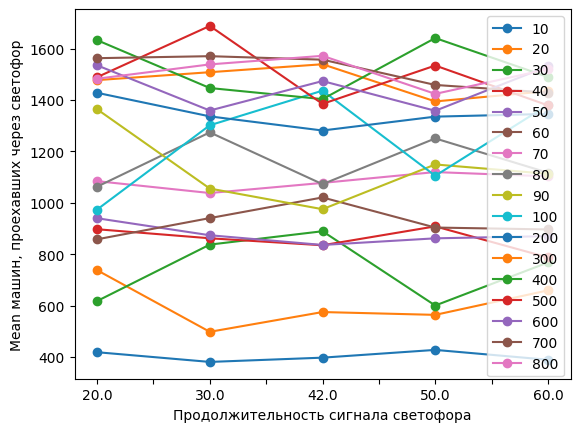

In [440]:
importlib.reload(analysis)

analysis.plots_mean_traffic(durations=durations, vehicles=vehicles_arr, pathToSave=gridsDataFolder)

----------running for duration:  20 -------------


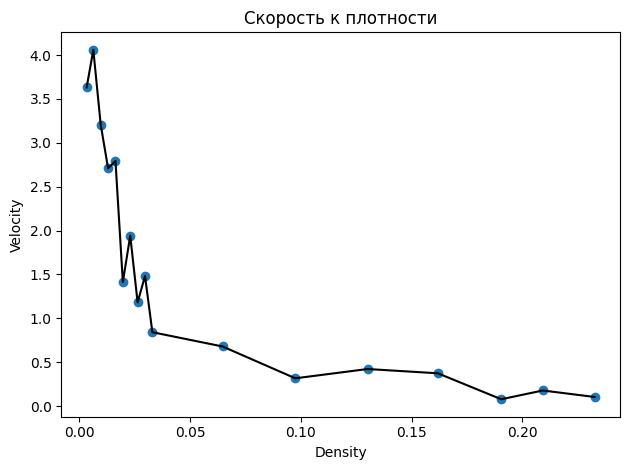

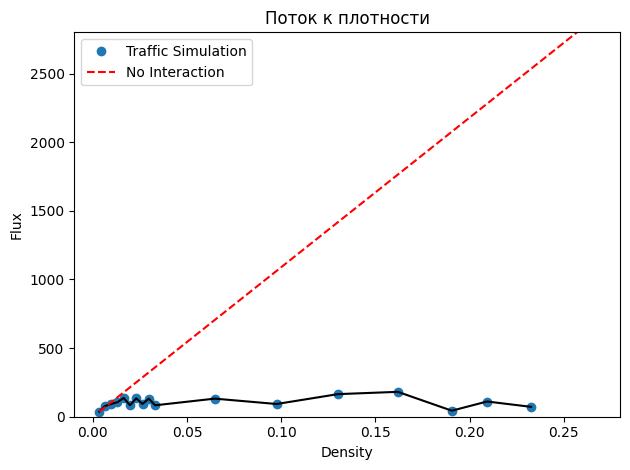

----------running for duration:  30 -------------


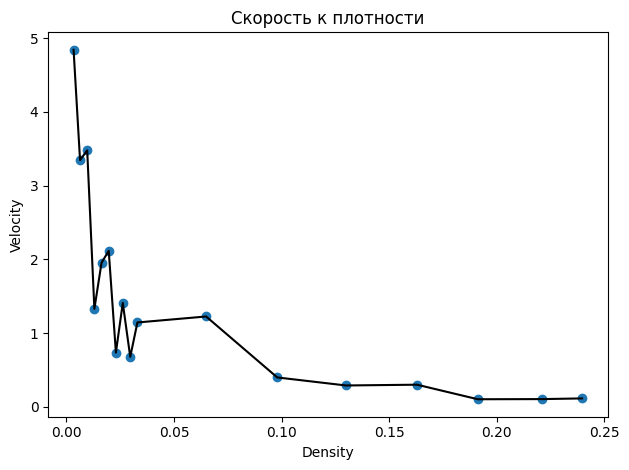

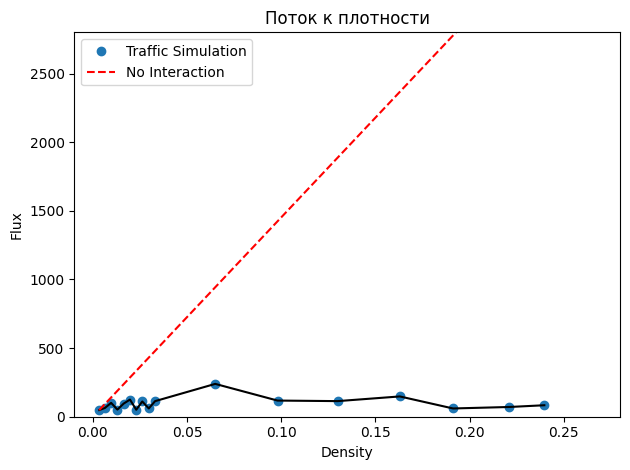

----------running for duration:  42 -------------


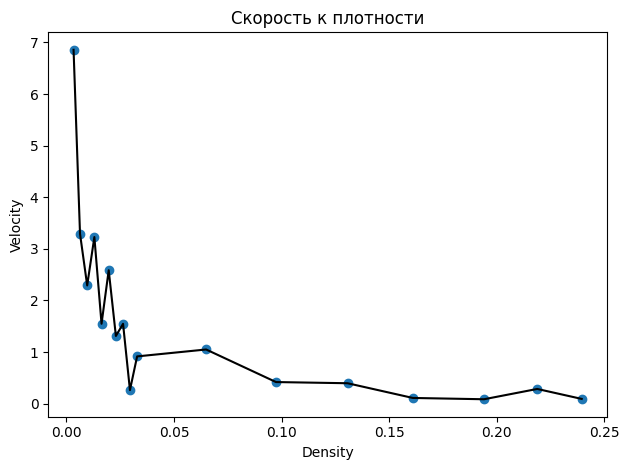

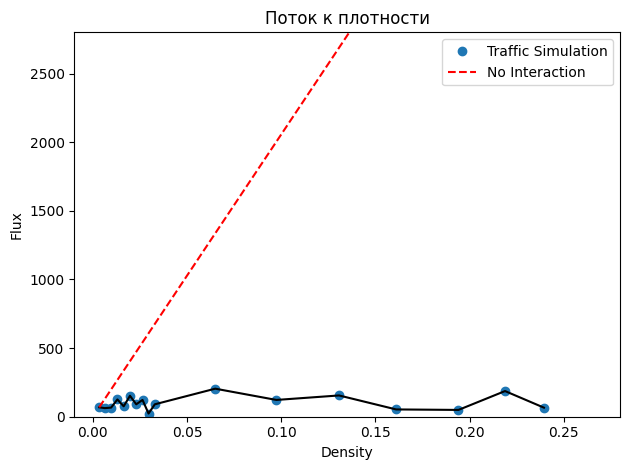

----------running for duration:  50 -------------


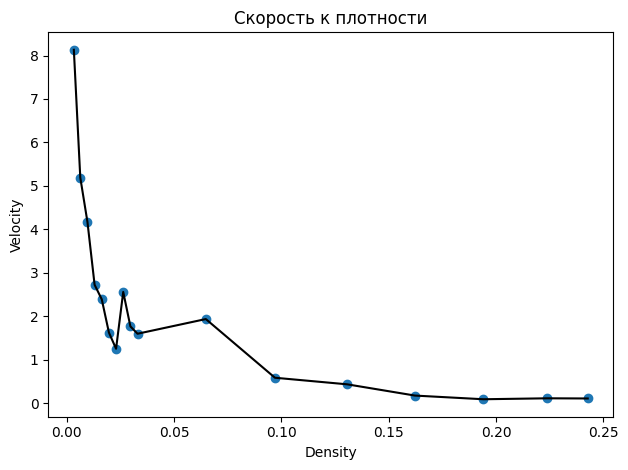

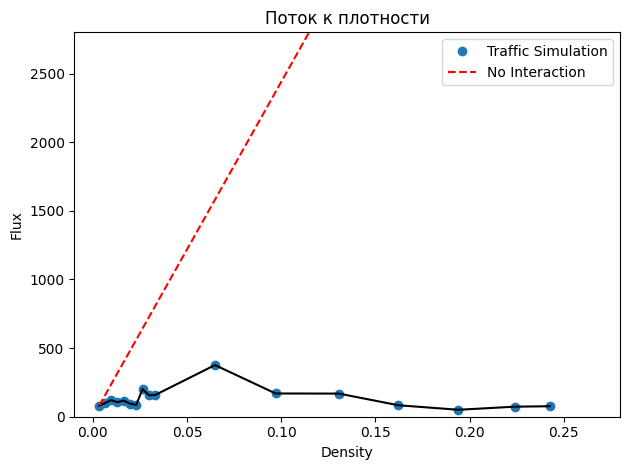

----------running for duration:  60 -------------


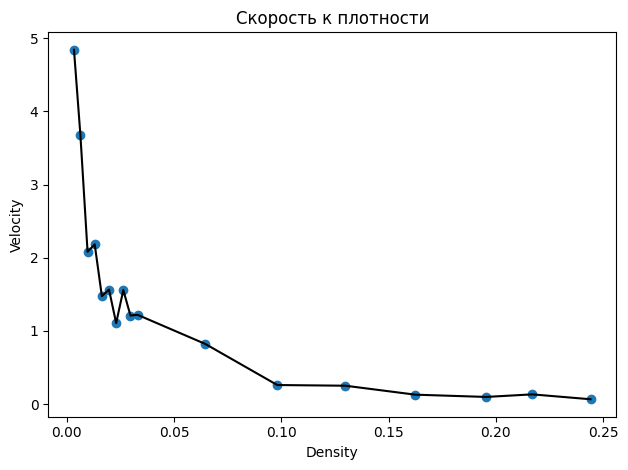

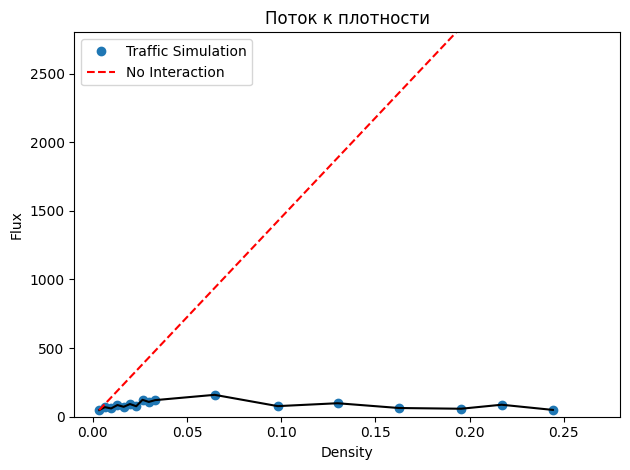

In [426]:
for duration in durations:
    print("----------running for duration: ", duration,"-------------")
    get_plots(                     
            vehicles_arr=vehicles_arr,
            pathToSave=gridsDataFolder,
            green_faze=duration,
            red_faze=duration
    )

# Analysysys


In [547]:
importlib.reload(analysis)

<module 'functions.analysis' from 'c:\\Users\\Yura Sannikov\\Учеба\\НИР-диплом26\\Папка с кодомм\\git\\functions\\analysis.py'>

In [561]:
def getLastRowInfo(df_data_run):
    return df_data_run.groupby('tls_id').tail(1)[['tls_id', 'jams_count', 'jams_time', 'jams_car_count']]

def getPassedCarsAsRows(df_data_passed):
    return df_data_passed.melt(var_name='tls_id', value_name='total_cars_passed')

def mergeDFsonTlsId(df1, df2):
    return df1.merge(df2, on='tls_id', how='left')

def timeOnRedDF(df_data_run):
    # Создаем столбец с пострoчным расчетом
    df_data_run['real_time_on_red'] = 0
    df_data_run.loc[df_data_run['is_green_horizontal'] == 0, 'real_time_on_red'] += df_data_run['count_to_r'] + df_data_run['count_to_l']
    df_data_run.loc[df_data_run['is_green_vertical'] == 0, 'real_time_on_red'] += df_data_run['count_to_b'] + df_data_run['count_to_t']

    # Группируем и суммируем
    return df_data_run.groupby('tls_id')['real_time_on_red'].sum().reset_index()

def getCollectedInfo(path_to_run_info, path_to_passed_info, id_postfix = ''):
    '''Формирует один dataFrame по собранной информации для метрик'''
    df_data_run = pd.read_csv(path_to_run_info)
    df_data_passed = pd.read_csv(path_to_passed_info)

    df_data_run_jam_info = getLastRowInfo(df_data_run)
    df_data_passed_T = getPassedCarsAsRows(df_data_passed)
    real_time_on_red_df = timeOnRedDF(df_data_run)
    
    df_run_with_passed = mergeDFsonTlsId(df_data_run_jam_info, df_data_passed_T)
    result = mergeDFsonTlsId(df_run_with_passed, real_time_on_red_df)
    result['tls_id'] = result['tls_id'].astype(str) + id_postfix
    return result

def addTotalInfo(allInfoDF):
    allInfoDF_copy = allInfoDF.copy()
    # Извлекаем постфикс из tls_id
    allInfoDF_copy['postfix'] = allInfoDF_copy['tls_id'].str.extract(r'_(veh_\d+_.+)')

    # Список столбцов для суммирования
    numeric_cols = ['jams_count', 'jams_time', 'jams_car_count', 'total_cars_passed', 'real_time_on_red']

    # Группируем по постфиксу и суммируем
    grouped = allInfoDF_copy.groupby('postfix')[numeric_cols].sum().reset_index()

    # Создаем строки с tls_id = f'total_{postfix}'
    grouped['tls_id'] = 'total_' + grouped['postfix']
    # grouped['id'] = range(len(grouped))  # или другой способ задания id

    # Убираем постфикс (он больше не нужен)
    grouped = grouped.drop('postfix', axis=1)
    # Добавляем в исходный DataFrame
    with_total = pd.concat([allInfoDF_copy, grouped], ignore_index=True)
    # Убираем постфикс (он больше не нужен)
    return with_total.drop('postfix', axis=1)



In [459]:
path_to_run_info = 'predict_runs/runInfo_v200_g30_predict.csv'
path_to_passed_info = 'gridsData/predict/fazes_g30r_30/dataFor_200_vehicles/all_sums_200.csv'

In [476]:
collectedInfo = getCollectedInfo(path_to_run_info, path_to_passed_info)
print(collectedInfo)

  tls_id  jams_count  jams_time  jams_car_count  total_cars_passed  \
0     A1          43        283              72               7080   
1     B0          27        141              43               7062   
2     B1         203       1916             277               6947   
3     B2          51        394              91               6955   
4     C1          29        211              46               6951   

   real_time_on_red  
0              2888  
1              4313  
2              2303  
3              3165  
4              2630  


In [486]:
vehicles_arr

array([ 200,  400,  600,  800, 1000])

In [558]:
def getAllCollectedInfo():
    allCollectedInfo = pd.DataFrame()

    for veh_cnt in vehicles_arr:
        # print('++',veh_cnt,'++')
        # print('--predict--')
        postfix_id = f"_veh_{veh_cnt}"
        postfix_pred = f"{postfix_id}_predict"
        path_to_run_info = analysis.getRunInfoPath(vehicles_count=veh_cnt,phaseDuration=30, withModel=True)
        path_to_passed_info = analysis.get_csvFazesPath(analysis.get_dataFolder(gridsDataFolder, veh_cnt, green_faze=30, red_faze=30, withModel=True), veh_cnt)
        collectedInfo = getCollectedInfo(path_to_run_info, path_to_passed_info, postfix_pred)
        if len(allCollectedInfo) == 0:
            allCollectedInfo = collectedInfo
        else:
            allCollectedInfo = pd.concat([allCollectedInfo, collectedInfo], ignore_index=True)
        # print('--default--')
        for duration in durations:
            postfix_default = f"{postfix_id}_g{duration}"
            path_to_run_info = analysis.getRunInfoPath(vehicles_count=veh_cnt,phaseDuration=duration, withModel=False)
            path_to_passed_info = analysis.get_csvFazesPath(analysis.get_dataFolder(gridsDataFolder, veh_cnt, green_faze=duration, red_faze=duration, withModel=False), veh_cnt)
            collectedInfo = getCollectedInfo(path_to_run_info, path_to_passed_info, postfix_default)
            allCollectedInfo = pd.concat([allCollectedInfo, collectedInfo], ignore_index=True)
    # добавляем строки с общей информацией по симуляции
    return addTotalInfo(allCollectedInfo)


In [562]:
allInfoDF = getAllCollectedInfo()

In [563]:
allInfoDF

,tls_id,jams_count,jams_time,jams_car_count,total_cars_passed,real_time_on_red
0,A1_veh_200_predict,43,283,72,7080,2888
1,B0_veh_200_predict,27,141,43,7062,4313
2,B1_veh_200_predict,203,1916,277,6947,2303
3,B2_veh_200_predict,51,394,91,6955,3165
4,C1_veh_200_predict,29,211,46,6951,2630
...,...,...,...,...,...,...
175,total_veh_800_g30,56,313,77,33006,39898
176,total_veh_800_g42,10,95,14,29672,29152
177,total_veh_800_g50,2,5,3,29854,25257
178,total_veh_800_g60,0,0,0,30655,21353


In [ ]:
# def get_plots(vehicles_arr, pathToSave, green_faze=30, red_faze=30, withModel=False):
#     analysis.plots(vehicles_arr, pathToSave, green_faze=green_faze, red_faze=red_faze)

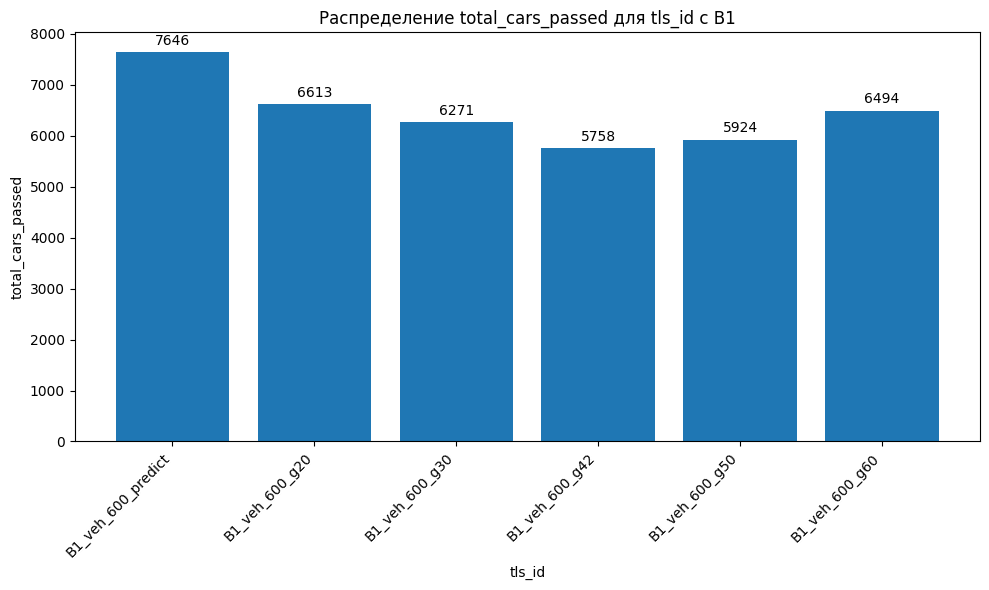

In [ ]:

# # Фильтруем строки, где tls_id содержит "B1"
# df_b1 = allInfoDF[allInfoDF['tls_id'].str.contains('B1_veh_600', na=False)]

# column = 'total_cars_passed'
# # Строим гистограмму
# plt.figure(figsize=(10, 6))
# bars = plt.bar(df_b1['tls_id'], df_b1[column])
# plt.bar_label(bars, fmt='%d', fontsize=10, padding=3)

# plt.xlabel('tls_id')
# plt.ylabel(column)
# plt.title(f'Распределение {column} для tls_id с B1')
# plt.xticks(rotation=45, ha='right')
# plt.tight_layout()
# plt.show()

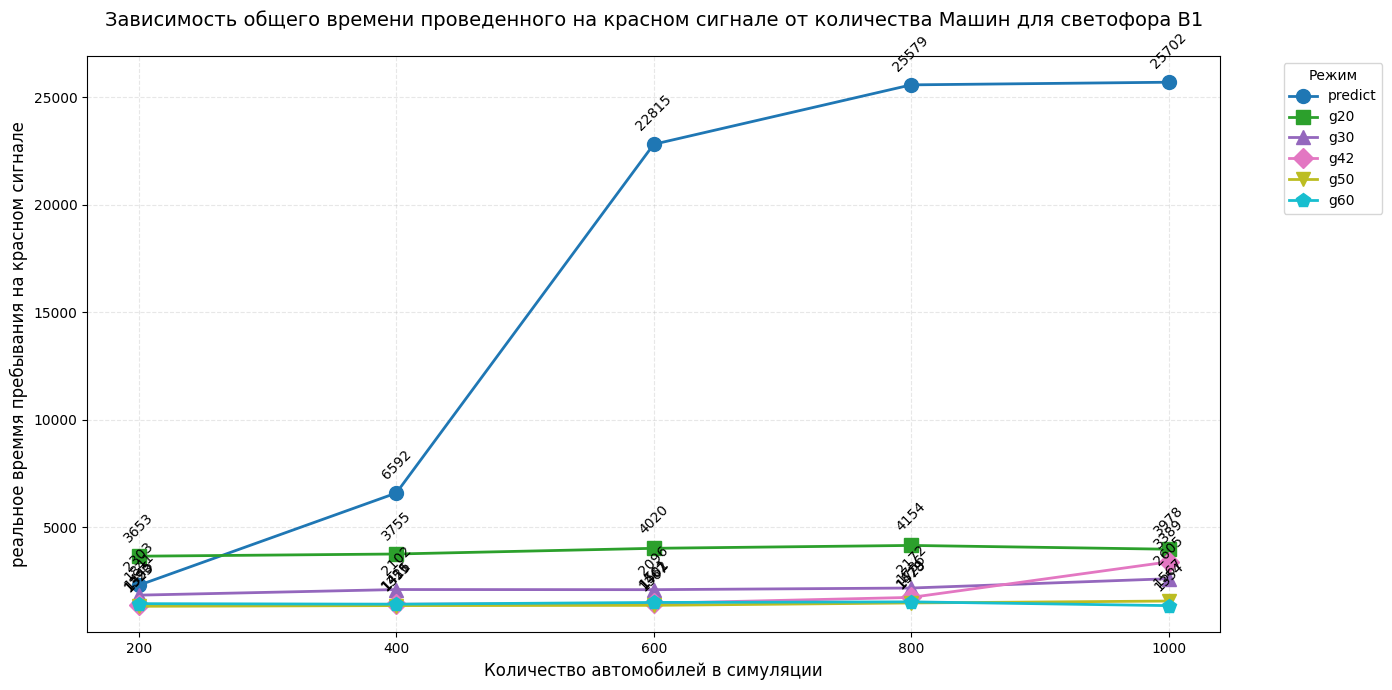

In [551]:
tlsId ='B1'
title = f'Зависимость общего времени проведенного на красном сигнале от количества Машин для светофора {tlsId}\n'
analysis.plotTidLineGraf(allInfoDF, tlsId, 'real_time_on_red', 'реальное времмя пребывания на красном сигнале', title)

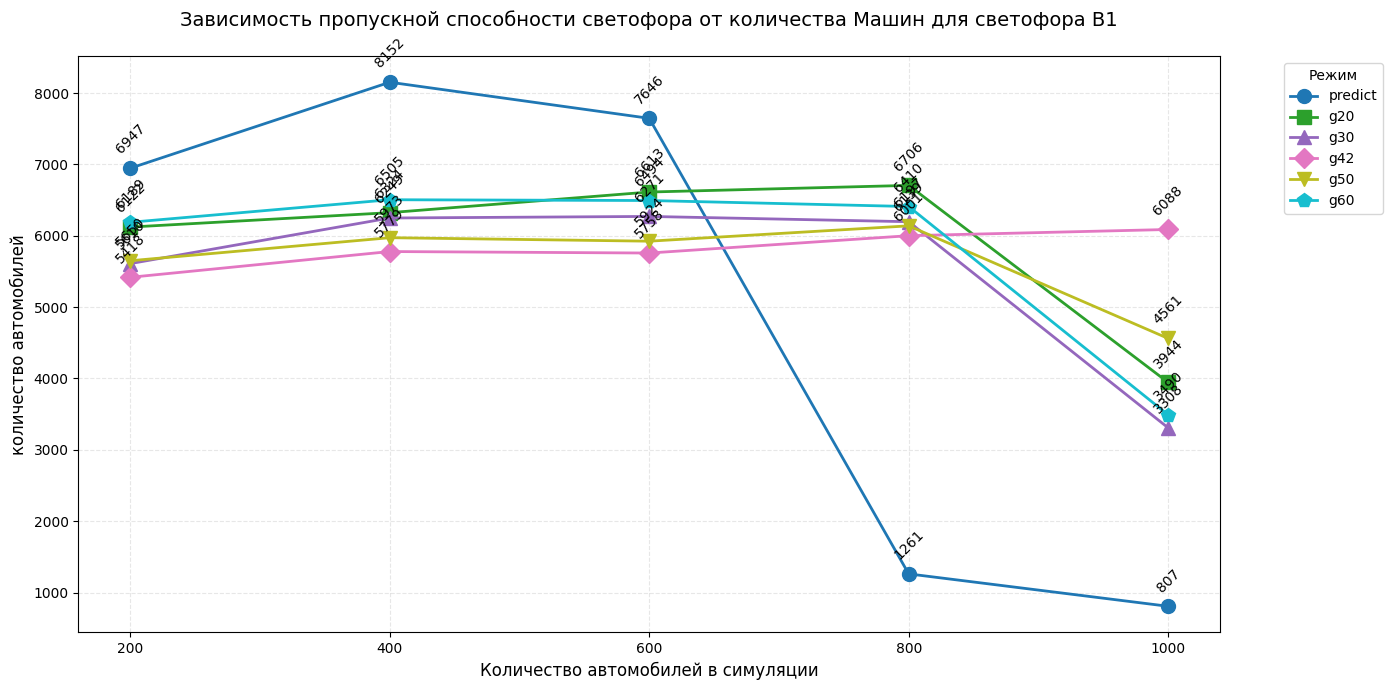

In [ ]:
tlsId ='B1'
title = f'Зависимость пропускной способности светофора от количества Машин для светофора {tlsId}\n'
analysis.plotTidLineGraf(allInfoDF, tlsId, 'total_cars_passed', 'количество автомобилей', title)

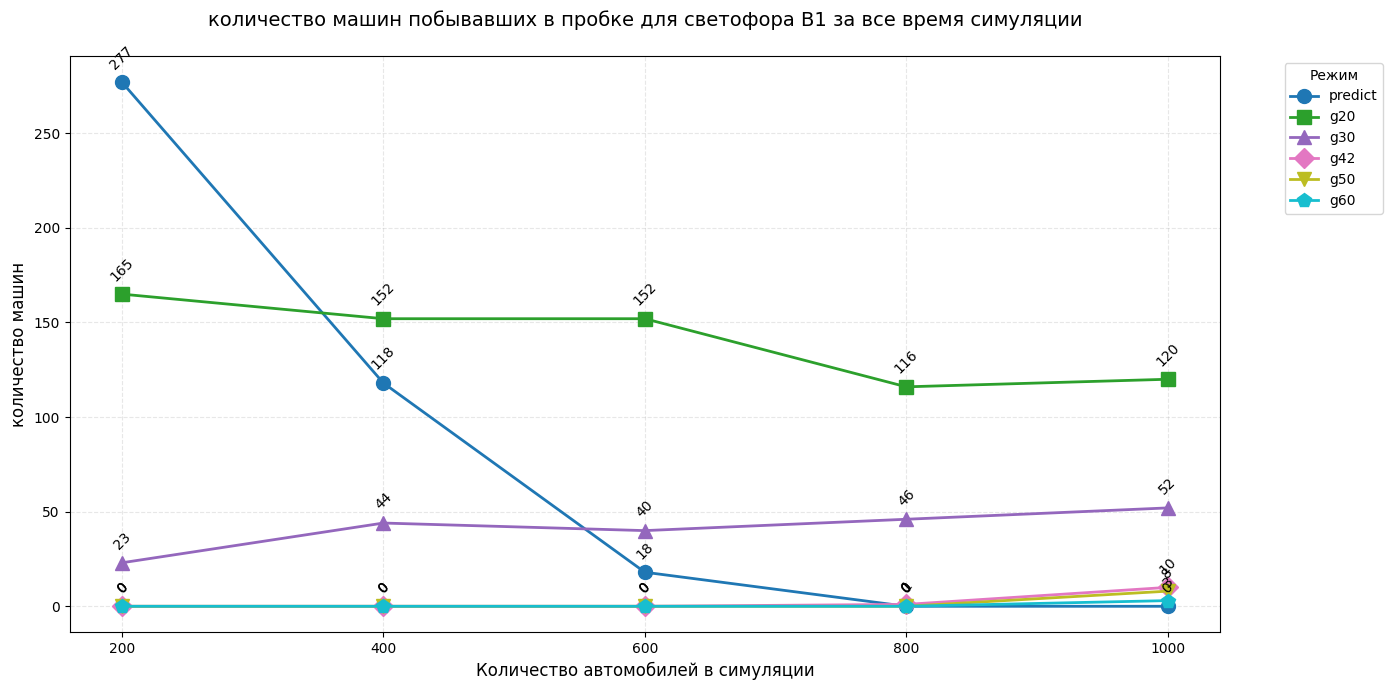

In [553]:
tlsId ='B1'
title = f'количество машин побывавших в пробке для светофора {tlsId} за все время симуляции\n'
analysis.plotTidLineGraf(allInfoDF, tlsId, 'jams_car_count', 'количество машин', title)

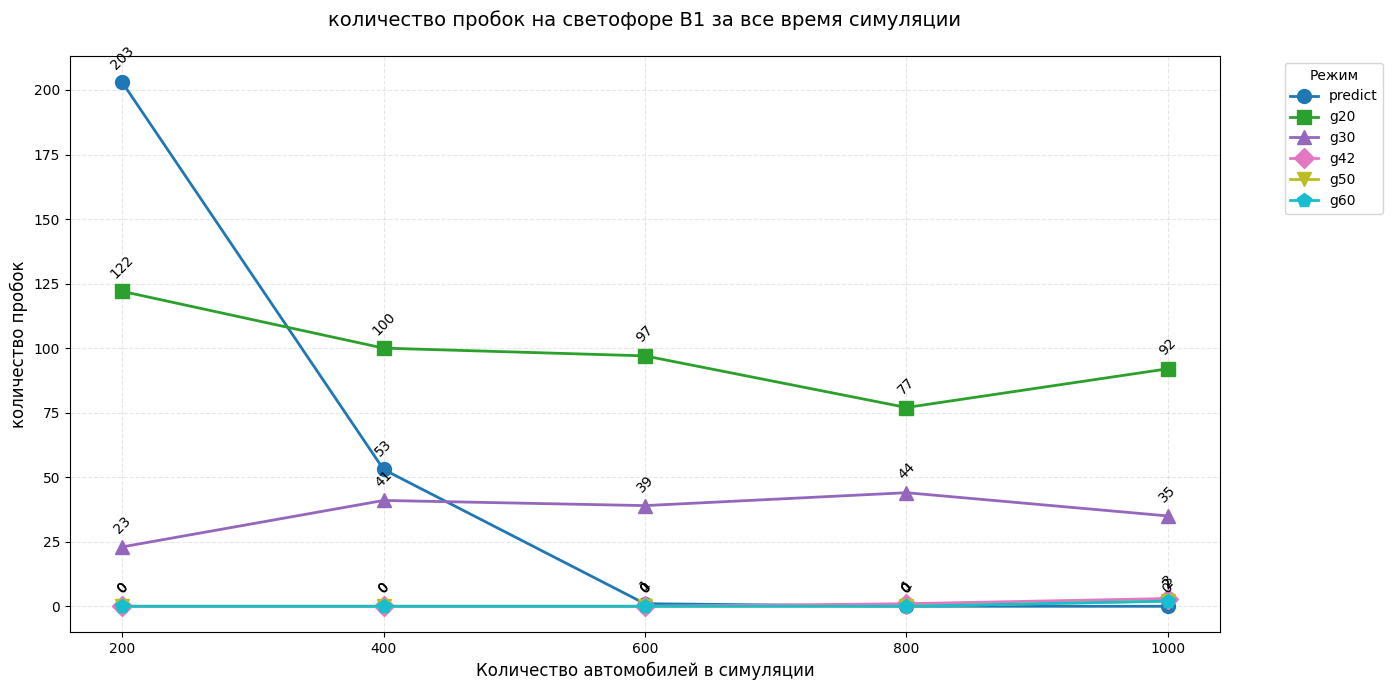

In [554]:
tlsId ='B1'
title = f'количество пробок на светофоре {tlsId} за все время симуляции\n'
analysis.plotTidLineGraf(allInfoDF, tlsId, 'jams_count', 'количество пробок', title)

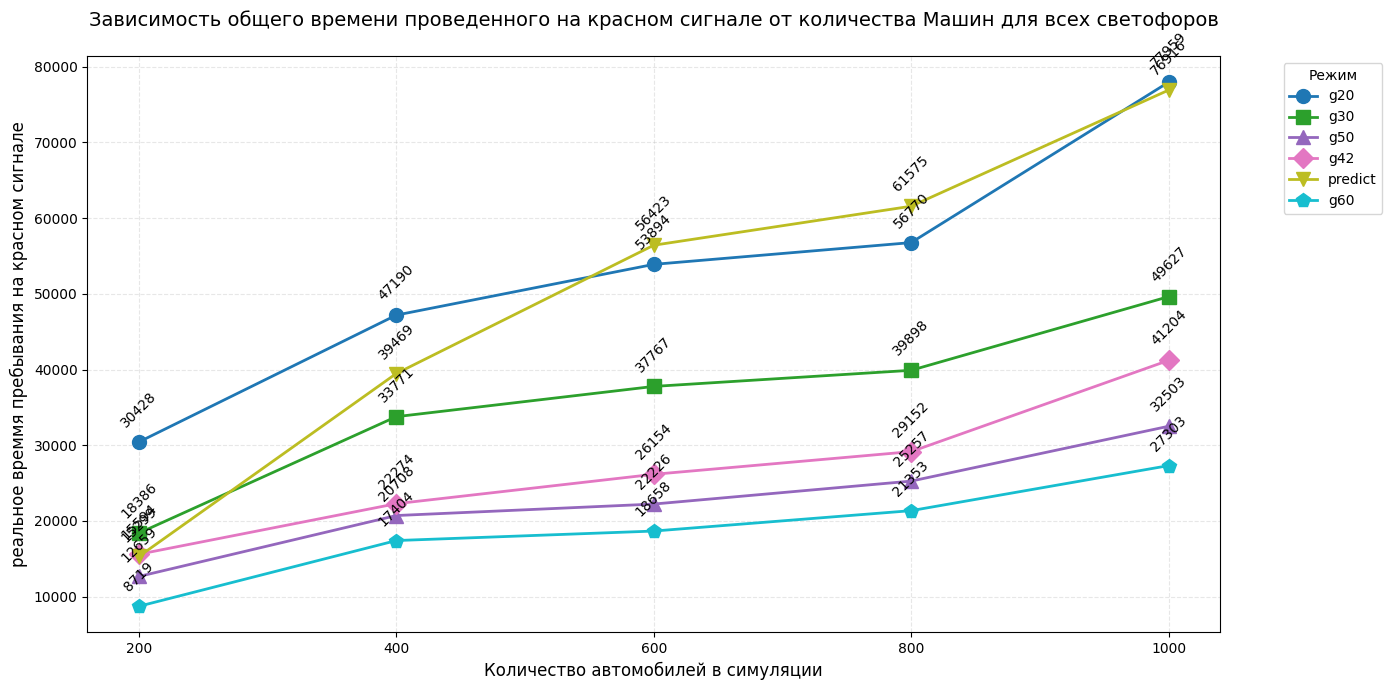

In [567]:
tlsId ='total'
title = f'Зависимость общего времени проведенного на красном сигнале от количества Машин для всех светофоров\n'
analysis.plotTidLineGraf(allInfoDF, tlsId, 'real_time_on_red', 'реальное времмя пребывания на красном сигнале', title)

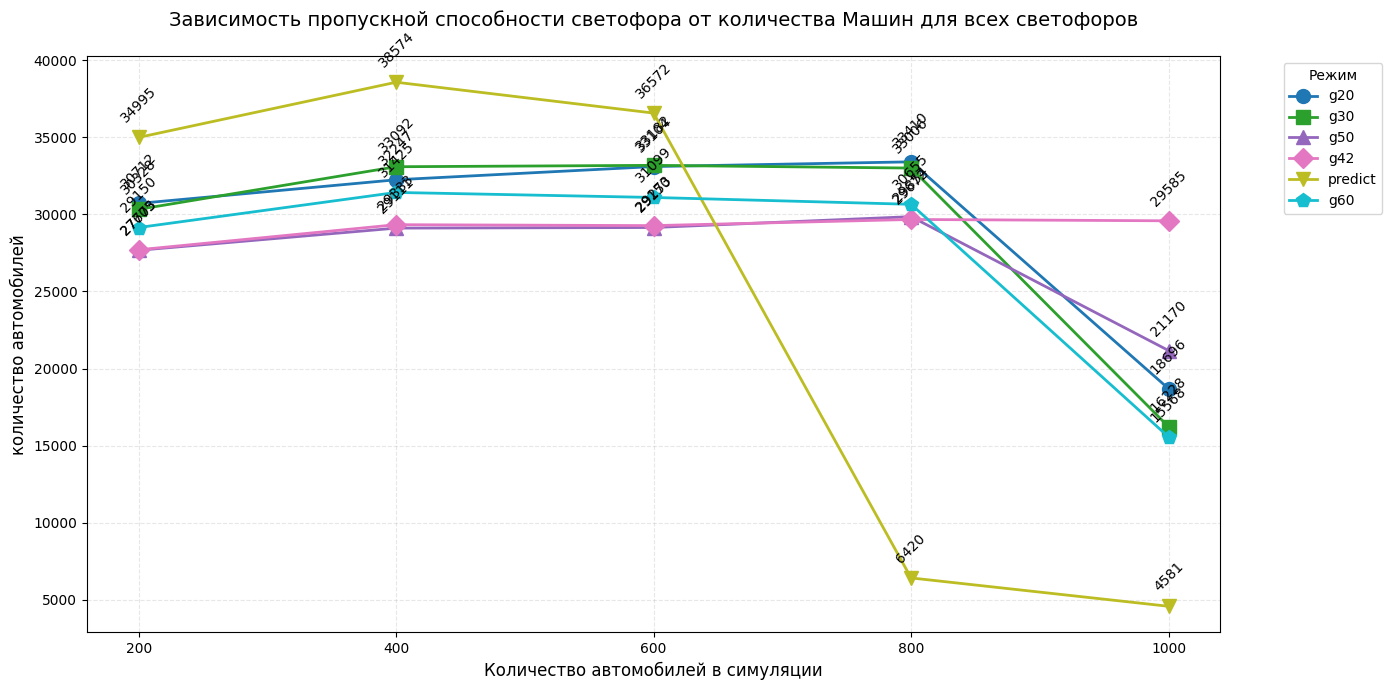

In [568]:
tlsId ='total'
title = f'Зависимость пропускной способности светофора от количества Машин для всех светофоров\n'
analysis.plotTidLineGraf(allInfoDF, tlsId, 'total_cars_passed', 'количество автомобилей', title)

По результатам анализа симуляций можно сказать, что Модель предсказания раюотает верно, но из-за того, что задание ппараметров для симуляции было неверное, эффективность такого метода страдает

Скорее всего проблема алгоритма симуляции это неправильное определение пробки перед светофором, нужно определять этот параметр в зависимости от времени, а не переключения фаз светофора.

Из вариантов улучшения симуляции:
1) определять пробку  по скорости автомобиля,
2) определять пробку по времени проведенном на красном сигнале светофора